<a href="https://colab.research.google.com/github/hermescosta/Statistical-Modeling/blob/main/Projeto_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Marketing bancário: prevendo quem adere ao depósito a prazo**
### Regressão logística e *random forest* implementadas do zero em R



## Introdução

Toda campanha de telemarketing tem um custo por ligação e uma equipe limitada. A pergunta de negócio é direta: *de toda a base de clientes, em quem vale a pena gastar uma ligação?* Este projeto responde a isso construindo um classificador que estima a probabilidade de cada cliente aderir a um **depósito a prazo**, para ordenar a carteira por propensão e priorizar os contatos certos.

Usa-se a base **Bank Marketing** (UCI; Moro, Cortez e Rita, 2014), de campanhas reais de um banco português. A variável resposta é `y` (adesão: "Sim"/"Não"), sendo "Sim" a classe de interesse. A variável `duration` (duração da ligação) é descartada por ser **vazamento** — só é conhecida depois do contato, e o modelo precisa decidir *antes* de ligar.

O diferencial técnico é a **implementação manual**: a regressão logística, a *random forest*, a descida do gradiente, as árvores CART, a otimização bayesiana e todas as métricas (ROC, AUC, F1) foram escritas em base R, **sem pacotes que implementem o modelo, o treino, a predição ou as métricas**. Pacotes externos entram só para ler, manipular e visualizar.

O fio condutor do trabalho é o **desbalanceamento** (~12,7% de "Sim" após a limpeza), que torna a acurácia enganosa e exige métricas voltadas à classe minoritária — sensibilidade (*recall*), precisão e F1 — além de estratégias específicas de balanceamento.




## 0. Configuração inicial

Define a semente de reprodutibilidade, localiza a base de dados, define as variáveis numéricas/categóricas, a paleta de cores usada nos gráficos e os dicionários de tradução (nome técnico → português) usados para rotular tabelas e figuras ao longo do notebook.

In [110]:

SEED <- 20260523
set.seed(SEED)

encontrar_base <- function(arquivo = "bank-additional-full.csv") {
  dirs <- character(0)
  args <- commandArgs(FALSE)
  f <- sub("^--file=", "", grep("^--file=", args, value = TRUE))
  if (length(f)) dirs <- c(dirs, dirname(normalizePath(f[1], mustWork = FALSE)))
  for (i in seq_len(sys.nframe())) {
    of <- sys.frame(i)$ofile
    if (!is.null(of)) { dirs <- c(dirs, dirname(normalizePath(of, mustWork = FALSE))); break }
  }
  d <- getwd()
  for (i in 0:4) { dirs <- c(dirs, d); d <- dirname(d) }
  dirs <- unique(c(dirs, dirname(dirs)))
  for (dd in dirs) {
    p <- file.path(dd, arquivo)
    if (file.exists(p)) return(normalizePath(p))
  }
  stop("Arquivo '", arquivo, "' nao encontrado. Coloque-o na pasta do projeto ",
       "ou use Session > Set Working Directory > To Source File Location.",
       call. = FALSE)
}

DATA_PATH <- encontrar_base("bank-additional-full.csv")
PROJ_DIR  <- dirname(DATA_PATH)

# Saida dos graficos. Por padrao (TRUE) as figuras sao desenhadas no painel
# "Plots" do R (RStudio), sem salvar nenhum arquivo; navegue pelas setas do
# painel. Defina MOSTRAR_PLOTS <- FALSE para, em vez disso, gerar os PNG em
# output/figures (util apenas se for montar o relatorio em HTML).
MOSTRAR_PLOTS <- TRUE
FIG_DIR <- file.path(PROJ_DIR, "output", "figures")

VAR_TARGET   <- "y"
VARS_NUM <- c("age", "duration", "campaign", "pdays", "previous",
              "emp.var.rate", "cons.price.idx", "cons.conf.idx",
              "euribor3m", "nr.employed")
VARS_CAT <- c("job", "marital", "education", "default", "housing",
              "loan", "contact", "month", "day_of_week", "poutcome")
VARS_LEAKAGE <- c("duration")

COR_NAO <- "#4C72B0"
COR_SIM <- "#C44E52"
COR_NEU <- "#55A868"

abrir_fig <- function(nome, largura = 1100, altura = 750, res = 130) {
  if (isTRUE(MOSTRAR_PLOTS)) {
    # Exibe no painel "Plots" do R: cada figura ocupa uma nova pagina. Reinicia
    # os parametros graficos para nao herdar mfrow/mar da figura anterior.
    par(mfrow = c(1, 1), mar = c(5.1, 4.1, 4.1, 2.1))
  } else {
    if (!dir.exists(FIG_DIR)) dir.create(FIG_DIR, recursive = TRUE)
    png(file.path(FIG_DIR, paste0(nome, ".png")), width = largura, height = altura, res = res)
  }
}

# Encerra a figura: fecha o dispositivo PNG quando se esta salvando em arquivo;
# no modo de exibicao nao ha nada a fechar (o grafico ja esta no painel Plots).
fechar_fig <- function() {
  if (!isTRUE(MOSTRAR_PLOTS)) dev.off()
  invisible()
}

# Traducao
TR_VAR <- c(
  age = "Idade", job = "Profissao", marital = "Estado civil",
  education = "Escolaridade", default = "Inadimplencia",
  housing = "Financiamento imobiliario", loan = "Emprestimo pessoal",
  contact = "Meio de contato", month = "Mes do ultimo contato",
  day_of_week = "Dia da semana do contato", duration = "Duracao do contato (s)",
  campaign = "Contatos nesta campanha", pdays = "Dias desde ultimo contato",
  previous = "Contatos anteriores", poutcome = "Resultado da campanha anterior",
  emp.var.rate = "Taxa de variacao do emprego",
  cons.price.idx = "Indice de precos ao consumidor",
  cons.conf.idx = "Indice de confianca do consumidor",
  euribor3m = "Euribor 3 meses", nr.employed = "Numero de empregados",
  contatado_antes = "Contatado antes (sim/nao)", y = "Aderiu ao deposito a prazo")

TR_VAR_CURTO <- c(
  age = "Idade", duration = "Duracao", campaign = "Contatos",
  pdays = "Dias ult.ct", previous = "Ct. anter.", emp.var.rate = "Tx. emprego",
  cons.price.idx = "IPC", cons.conf.idx = "ICC", euribor3m = "Euribor 3m",
  nr.employed = "No empregados", contatado_antes = "Contat. antes")

TR_NIVEL <- list(
  job = c("admin." = "Administrativo", "blue-collar" = "Operario",
          "entrepreneur" = "Empreendedor", "housemaid" = "Domestica",
          "management" = "Gerencia", "retired" = "Aposentado",
          "self-employed" = "Autonomo", "services" = "Servicos",
          "student" = "Estudante", "technician" = "Tecnico",
          "unemployed" = "Desempregado", "unknown" = "Desconhecido"),
  marital = c("married" = "Casado", "single" = "Solteiro",
              "divorced" = "Divorciado", "unknown" = "Desconhecido"),
  education = c("basic.4y" = "Fundamental 4a", "basic.6y" = "Fundamental 6a",
               "basic.9y" = "Fundamental 9a", "high.school" = "Medio",
               "illiterate" = "Analfabeto", "professional.course" = "Profissionalizante",
               "university.degree" = "Superior", "unknown" = "Desconhecido"),
  default = c("no" = "Nao", "yes" = "Sim", "unknown" = "Desconhecido"),
  housing = c("no" = "Nao", "yes" = "Sim", "unknown" = "Desconhecido"),
  loan = c("no" = "Nao", "yes" = "Sim", "unknown" = "Desconhecido"),
  contact = c("cellular" = "Celular", "telephone" = "Telefone fixo"),
  month = c("mar" = "Mar", "apr" = "Abr", "may" = "Mai", "jun" = "Jun",
            "jul" = "Jul", "aug" = "Ago", "sep" = "Set", "oct" = "Out",
            "nov" = "Nov", "dec" = "Dez"),
  day_of_week = c("mon" = "Seg", "tue" = "Ter", "wed" = "Qua",
                  "thu" = "Qui", "fri" = "Sex"),
  poutcome = c("failure" = "Fracasso", "nonexistent" = "Inexistente",
               "success" = "Sucesso"),
  y = c("no" = "Nao", "yes" = "Sim"))

pt_var       <- function(v) ifelse(v %in% names(TR_VAR), TR_VAR[v], v)
pt_var_curto <- function(v) ifelse(v %in% names(TR_VAR_CURTO), TR_VAR_CURTO[v], pt_var(v))
pt_niveis <- function(var, niveis) {
  mapa <- TR_NIVEL[[var]]
  if (is.null(mapa)) return(as.character(niveis))
  out <- mapa[as.character(niveis)]
  out[is.na(out)] <- as.character(niveis)[is.na(out)]
  unname(out)
}

### 0.1 Funções de leitura e limpeza dos dados

Funções para ler o CSV original, remover duplicatas e linhas com valores `"unknown"`, montar a codificação *one-hot* das categóricas, padronizar (z-score) com parâmetros estimados apenas no treino, e gerar os índices de particionamento estratificado e de *undersampling*.

In [111]:
# --- Leitura, limpeza e transformacao ---

ler_dados <- function(path = DATA_PATH) {
  read.csv(path, sep = ";", stringsAsFactors = FALSE, na.strings = c("NA"),
           check.names = TRUE)
}

# Remove duplicatas e linhas com 'unknown'. Devolve base bruta, base limpa e log.
limpar_base <- function(path = DATA_PATH, vars_unknown = VARS_CAT) {
  d0 <- ler_dados(path); n0 <- nrow(d0)
  d1 <- d0[!duplicated(d0), ]; n1 <- nrow(d1)
  tem_unk <- apply(d1[, vars_unknown, drop = FALSE], 1, function(r) any(r == "unknown"))
  d2 <- d1[!tem_unk, ]; n2 <- nrow(d2)
  cat("== 1. LIMPEZA (antes -> depois) ==\n")
  cat("  Base bruta...................:", n0, "linhas\n")
  cat("  Duplicatas removidas.........:", n0 - n1, "-> restam", n1, "\n")
  cat("  Linhas com 'unknown' removidas:", n1 - n2, "-> restam", n2, "\n")
  cat(sprintf("  TOTAL removido...............: %d (%.1f%% da base bruta)\n",
              n0 - n2, 100 * (n0 - n2) / n0))
  list(bruto = d0, limpa = d2,
       log = data.frame(
         etapa = c("Base bruta", "Apos duplicatas", "Apos remover 'unknown'"),
         linhas = c(n0, n1, n2)))
}

one_hot <- function(df, vars) {
  blocos <- lapply(vars, function(v) {
    f  <- factor(df[[v]])
    mm <- model.matrix(~ f - 1)
    colnames(mm) <- paste0(v, "_", levels(f))
    mm
  })
  do.call(cbind, blocos)
}

construir_design <- function(df, num_keep, cat_keep) {
  cbind(as.matrix(df[, num_keep, drop = FALSE]), one_hot(df, cat_keep))
}

# z-score com parametros estimados so no treino.
padronizar_ajuste <- function(X_tr) {
  mu <- colMeans(X_tr); sigma <- apply(X_tr, 2, sd); sigma[sigma == 0] <- 1
  list(mu = mu, sigma = sigma)
}
padronizar_aplicar <- function(M, par) sweep(sweep(M, 2, par$mu, "-"), 2, par$sigma, "/")

indices_treino_estratificado <- function(rotulo, prop = 0.70) {
  idx <- integer(0)
  for (cl in levels(rotulo)) {
    idx_cl <- which(rotulo == cl)
    idx <- c(idx, sample(idx_cl, floor(prop * length(idx_cl))))
  }
  sort(idx)
}

# Undersampling da classe majoritaria (todos os "yes" + razao*esse total de "no").
random_undersample <- function(rotulo, razao = 2, semente = SEED) {
  set.seed(semente)
  idx_min <- which(rotulo == "yes"); idx_maj <- which(rotulo == "no")
  n_keep <- min(length(idx_maj), round(razao * length(idx_min)))
  sort(c(idx_min, sample(idx_maj, n_keep)))
}

### 0.2 Funções de avaliação (métricas)

Implementação manual da matriz de confusão e das métricas voltadas à classe minoritária (acurácia, sensibilidade/recall, especificidade, precisão e F1), além do cálculo de AUC-ROC por estatística de postos e da função que desenha a matriz de confusão como mapa de calor — usada em praticamente todas as etapas de avaliação a seguir.

A partir da matriz de confusão (VP, VN, FP, FN):

$$\text{Acurácia}=\frac{VP+VN}{VP+VN+FP+FN},\qquad \text{Recall}=\frac{VP}{VP+FN},\qquad \text{Precisão}=\frac{VP}{VP+FP}$$

$$\text{Especificidade}=\frac{VN}{VN+FP},\qquad F_1 = 2\cdot\frac{\text{Precisão}\cdot\text{Recall}}{\text{Precisão}+\text{Recall}}$$

Em base desbalanceada, *recall* e F1 da classe "Sim" são as métricas que orientam a decisão; a acurácia, isolada, engana.

In [112]:
# --- Metricas ---

avaliar <- function(real, pred) {
  real <- factor(real, levels = c("no", "yes"))
  pred <- factor(pred, levels = c("no", "yes"))
  mc <- table(Real = real, Predito = pred)
  TN <- mc["no","no"];  FP <- mc["no","yes"]
  FN <- mc["yes","no"]; TP <- mc["yes","yes"]
  acuracia      <- (TP + TN) / sum(mc)
  sensibilidade <- TP / (TP + FN)
  especificidade<- TN / (TN + FP)
  precisao      <- TP / (TP + FP)
  f1            <- 2 * precisao * sensibilidade / (precisao + sensibilidade)
  list(matriz = mc,
       metricas = data.frame(
         metrica = c("Acuracia", "Sensibilidade (recall sim)", "Especificidade",
                     "Precisao (sim)", "F1 (sim)"),
         valor = round(c(acuracia, sensibilidade, especificidade, precisao, f1), 4)))
}

# AUC pela estatistica de postos (robusta a empates).
auc_roc <- function(prob, y) {
  P <- sum(y == 1); N <- sum(y == 0)
  r <- rank(prob)
  (sum(r[y == 1]) - P * (P + 1) / 2) / (P * N)
}

curva_roc <- function(prob, y) {
  ord <- order(prob, decreasing = TRUE); ys <- y[ord]
  P <- sum(y == 1); N <- sum(y == 0)
  data.frame(taxa_fp = c(0, cumsum(ys == 0) / N),
             taxa_vp = c(0, cumsum(ys == 1) / P))
}

# Matriz de confusao como mapa de calor.
plot_matriz_confusao <- function(mc, arquivo, titulo) {
  prop_linha <- mc / rowSums(mc)
  classes    <- c("nao", "sim")
  tipos      <- matrix(c("VN", "FP", "FN", "VP"), nrow = 2, byrow = TRUE)
  abrir_fig(arquivo, largura = 850, altura = 800, res = 130)
  par(mar = c(5, 5.5, 4, 2))
  plot(0, 0, type = "n", xlim = c(0, 2), ylim = c(0, 2), xaxs = "i", yaxs = "i",
       xaxt = "n", yaxt = "n", xlab = "Classe predita", ylab = "Classe real",
       main = titulo)
  axis(1, at = c(0.5, 1.5), labels = classes, tick = FALSE)
  axis(2, at = c(1.5, 0.5), labels = classes, tick = FALSE, las = 1)
  for (i in 1:2) for (j in 1:2) {
    base_col <- if (i == j) COR_NEU else COR_SIM
    col_cell <- adjustcolor(base_col, alpha.f = 0.20 + 0.65 * prop_linha[i, j])
    ytop <- 2 - (i - 1); xleft <- j - 1
    rect(xleft, ytop - 1, xleft + 1, ytop, col = col_cell, border = "white", lwd = 4)
    text(xleft + 0.5, ytop - 0.5,
         sprintf("%s\n%d\n(%.1f%%)", tipos[i, j], mc[i, j], 100 * prop_linha[i, j]),
         font = 2, cex = 1.2)
  }
  fechar_fig()
}

### 0.3 Regressão Logística — funções centrais

Implementação manual dos quatro componentes do modelo logístico: a função sigmoide (em versão numericamente estável), a função de custo log-loss, a descida do gradiente em lote para estimar os coeficientes, e a regra de classificação por ponto de corte sobre a probabilidade estimada.

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad h_\beta(x) = P(y=1\mid x) = \sigma\Big(\beta_0 + \sum_{j=1}^{p}\beta_j x_j\Big)$$

Os coeficientes $\beta$ são estimados minimizando a **log-loss** (entropia cruzada) por **descida do gradiente**:

$$J(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\big[\,y_i\log h_\beta(x_i) + (1-y_i)\log(1-h_\beta(x_i))\,\big]$$

$$\beta \leftarrow \beta - \eta\,\frac{1}{n}\,X^{\top}\big(\sigma(X\beta)-y\big)$$

In [113]:
# --- Regressao logistica (sigmoide + log-loss + descida do gradiente) ---

# Remove 1 nivel de referencia por categorica e adiciona o intercepto.
montar_design <- function(X, cat_keep) {
  cols <- colnames(X); ref_cols <- character(0)
  for (v in cat_keep) {
    cols_v <- cols[startsWith(cols, paste0(v, "_"))]
    if (length(cols_v) > 0) ref_cols <- c(ref_cols, cols_v[1])
  }
  list(X = cbind(`(Intercepto)` = 1, X[, setdiff(cols, ref_cols), drop = FALSE]),
       ref_cols = ref_cols)
}

sigmoide <- function(z) ifelse(z >= 0, 1 / (1 + exp(-z)), exp(z) / (1 + exp(z)))

custo_logistico <- function(p, y) {
  p <- pmin(pmax(p, 1e-15), 1 - 1e-15)
  -mean(y * log(p) + (1 - y) * log(1 - p))
}

# Para quando a variacao do custo fica abaixo de tol; guarda o historico do custo.
ajustar_logistica <- function(X, y, taxa = 0.3, max_iter = 30000, tol = 1e-7,
                              verbose = FALSE) {
  n <- nrow(X); beta <- rep(0, ncol(X)); custo_ant <- Inf
  historico <- numeric(0); convergiu <- FALSE
  for (it in seq_len(max_iter)) {
    p <- sigmoide(as.vector(X %*% beta))
    c_atual <- custo_logistico(p, y)
    historico <- c(historico, c_atual)
    if (abs(custo_ant - c_atual) < tol) { convergiu <- TRUE; break }
    custo_ant <- c_atual
    beta <- beta - taxa * (as.vector(crossprod(X, p - y)) / n)
    if (verbose && it %% 2000 == 0) cat(sprintf("    iter %6d | custo = %.6f\n", it, c_atual))
  }
  names(beta) <- colnames(X)
  list(beta = beta, iteracoes = it, custo_final = historico[length(historico)],
       convergiu = convergiu, historico = historico, taxa = taxa, tol = tol, corte = 0.5)
}

prever_prob <- function(modelo, X) as.vector(sigmoide(X %*% modelo$beta))
classificar <- function(prob, corte = 0.5) ifelse(prob >= corte, "yes", "no")

### 0.4 Random Forest — funções centrais

Implementação manual de um *ensemble* de árvores CART: impureza de Gini, busca do melhor corte por variável, construção recursiva da árvore, bootstrap balanceado por árvore (*Balanced Random Forest* — todos os "Sim" e o dobro desse total de "Não"), agregação por voto médio, avaliação Out-of-Bag (OOB) e importância das variáveis por redução de Gini.

$$G = 1-\sum_k p_k^2 = 2\,p\,(1-p), \qquad \hat p(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^{B}\hat p_b(\mathbf{x})$$

Em cada nó, escolhe-se o corte (variável $j$, limiar $t$) que minimiza a impureza de Gini **ponderada** dos filhos:

$$G_{\text{split}} = \frac{n_L}{n}\,G(\text{esq.}) + \frac{n_R}{n}\,G(\text{dir.})$$

In [114]:
# --- Random forest (Gini + CART + bootstrap balanceado + OOB) ---

impureza_gini <- function(y) { if (length(y) == 0) return(0); p <- mean(y); 2 * p * (1 - p) }

# (variavel, limiar) que minimiza a Gini ponderada dos filhos.
melhor_corte <- function(X, y, feats, n_cortes) {
  n <- length(y); melhor <- NULL; melhor_g <- impureza_gini(y)
  for (f in feats) {
    x <- X[, f]; u <- unique(x)
    if (length(u) < 2) next
    cortes <- if (length(u) <= n_cortes) sort(u)[-length(u)]
              else unique(quantile(x, probs = seq_len(n_cortes) / (n_cortes + 1),
                                   names = FALSE, type = 7))
    for (t in cortes) {
      mask <- x <= t; nL <- sum(mask); nR <- n - nL
      if (nL == 0 || nR == 0) next
      g <- (nL / n) * impureza_gini(y[mask]) + (nR / n) * impureza_gini(y[!mask])
      if (g < melhor_g) { melhor_g <- g; melhor <- list(feature = f, threshold = t, gini = g) }
    }
  }
  melhor
}

# Arvore CART recursiva (paradas: profundidade, minimo por no, no puro).
construir_arvore <- function(X, y, prof, mtry, max_prof, min_no, n_cortes) {
  n <- length(y); p_yes <- mean(y)
  if (prof >= max_prof || n < min_no || p_yes == 0 || p_yes == 1)
    return(list(folha = TRUE, prob = p_yes, n = n))
  feats <- sample(ncol(X), mtry)
  melhor <- melhor_corte(X, y, feats, n_cortes)
  if (is.null(melhor)) return(list(folha = TRUE, prob = p_yes, n = n))
  mask <- X[, melhor$feature] <= melhor$threshold
  if (all(mask) || !any(mask)) return(list(folha = TRUE, prob = p_yes, n = n))
  list(folha = FALSE, feature = melhor$feature, threshold = melhor$threshold,
       ganho = n * (impureza_gini(y) - melhor$gini), n = n,
       esq = construir_arvore(X[mask, , drop = FALSE],  y[mask],  prof + 1, mtry, max_prof, min_no, n_cortes),
       dir = construir_arvore(X[!mask, , drop = FALSE], y[!mask], prof + 1, mtry, max_prof, min_no, n_cortes))
}

prever_arvore <- function(arvore, X) {
  out <- numeric(nrow(X))
  rec <- function(no, idx) {
    if (no$folha) { out[idx] <<- no$prob; return(invisible()) }
    vals <- X[idx, no$feature]
    if (length(e <- idx[vals <= no$threshold])) rec(no$esq, e)
    if (length(d <- idx[vals >  no$threshold])) rec(no$dir, d)
  }
  rec(arvore, seq_len(nrow(X)))
  out
}

# Bootstrap balanceado: todos os "yes" + razao*esse total de "no" (com reposicao).
amostra_balanceada <- function(y, razao = 2) {
  iy <- which(y == 1); ino <- which(y == 0); ny <- length(iy)
  c(sample(iy, ny, replace = TRUE), sample(ino, round(razao * ny), replace = TRUE))
}

# B arvores balanceadas + predicoes out-of-bag.
treinar_floresta <- function(X, y, n_arvores = 60, mtry = NULL, max_prof = 12,
                             min_no = 40, n_cortes = 12, razao_bb = 2,
                             semente = SEED, verbose = FALSE) {
  set.seed(semente); n <- length(y)
  if (is.null(mtry)) mtry <- max(1, floor(sqrt(ncol(X))))
  arvores <- vector("list", n_arvores)
  oob_soma <- numeric(n); oob_cont <- integer(n)
  for (t in seq_len(n_arvores)) {
    idx <- amostra_balanceada(y, razao_bb)
    arvores[[t]] <- construir_arvore(X[idx, , drop = FALSE], y[idx], 0, mtry, max_prof, min_no, n_cortes)
    oob <- setdiff(seq_len(n), idx)
    if (length(oob)) {
      pr <- prever_arvore(arvores[[t]], X[oob, , drop = FALSE])
      oob_soma[oob] <- oob_soma[oob] + pr; oob_cont[oob] <- oob_cont[oob] + 1L
    }
    if (verbose && t %% 20 == 0) cat("    arvore", t, "/", n_arvores, "\n")
  }
  list(arvores = arvores, oob_prob = ifelse(oob_cont > 0, oob_soma / oob_cont, NA_real_),
       oob_cont = oob_cont,
       params = list(n_arvores = n_arvores, mtry = mtry, max_prof = max_prof, min_no = min_no))
}

prever_floresta <- function(floresta, X) {
  s <- numeric(nrow(X))
  for (a in floresta$arvores) s <- s + prever_arvore(a, X)
  s / length(floresta$arvores)
}

# Importancia por reducao de Gini (soma dos ganhos por variavel, normalizada).
importancia_floresta <- function(floresta, nomes) {
  imp <- numeric(length(nomes)); names(imp) <- nomes
  acumular <- function(no) {
    if (no$folha) return(invisible())
    imp[no$feature] <<- imp[no$feature] + no$ganho
    acumular(no$esq); acumular(no$dir)
  }
  for (a in floresta$arvores) acumular(a)
  if (sum(imp) > 0) imp <- imp / sum(imp)
  sort(imp, decreasing = TRUE)
}

### 0.5 Seleção de variáveis por correlação

Reimplementação manual da lógica da função `caret::findCorrelation()`: dado pares de variáveis com correlação absoluta acima de um limiar de redundância, remove-se a de maior correlação média com as demais.

A relevância de cada coluna com o alvo (0/1) é medida pela correlação de Pearson (ponto-bisserial nas numéricas, $\phi$ nas *dummies*): mantêm-se as colunas com $|r|\ge\tau=0{,}05$ e remove-se a redundância para $|\text{cor}|>\rho=0{,}80$.

$$r = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\,\sqrt{\sum_i (y_i-\bar y)^2}}$$

In [115]:
# --- Selecao por correlacao (findCorrelation reimplementado a mao) ---

find_correlation <- function(C, cutoff) {
  C <- abs(C); diag(C) <- NA
  meanAbs <- colMeans(C, na.rm = TRUE); removed <- integer(0)
  repeat {
    Ccur <- C
    if (length(removed)) { Ccur[removed, ] <- NA; Ccur[, removed] <- NA }
    mx <- suppressWarnings(max(Ccur, na.rm = TRUE))
    if (!is.finite(mx) || mx <= cutoff) break
    wh <- which(Ccur == mx, arr.ind = TRUE)[1, ]
    removed <- c(removed, if (meanAbs[wh[1]] >= meanAbs[wh[2]]) wh[1] else wh[2])
  }
  sort(unique(removed))
}

### 0.6 Otimização Bayesiana (Processo Gaussiano + Expected Improvement)

Implementação manual da otimização bayesiana usada no tuning da Random Forest (Seção 6.3): um Processo Gaussiano com kernel exponencial-quadrático modela a função objetivo (F1 por validação cruzada) e a aquisição *Expected Improvement* (EI) seleciona, a cada passo, o próximo conjunto de hiperparâmetros a avaliar.

$$\mathrm{EI}(\theta) = (\mu - f^+ - \xi)\,\Phi(Z) + \sigma\,\phi(Z), \qquad Z = \frac{\mu - f^+ - \xi}{\sigma}$$

In [116]:
# --- Otimizacao bayesiana (GP + Expected Improvement) + CV k-fold ---

kfold_estratificado <- function(y01, k = 4, semente = SEED) {
  set.seed(semente); folds <- integer(length(y01))
  for (cl in c(0L, 1L)) {
    idx <- sample(which(y01 == cl)); folds[idx] <- rep_len(seq_len(k), length(idx))
  }
  folds
}

subamostra_estratificada <- function(y01, n_alvo, semente = SEED) {
  set.seed(semente); prop <- min(1, n_alvo / length(y01)); idx <- integer(0)
  for (cl in c(0L, 1L)) {
    ic <- which(y01 == cl); idx <- c(idx, sample(ic, max(1, round(prop * length(ic)))))
  }
  sort(idx)
}

kernel_se <- function(A, B, l, sf2 = 1) {
  D2 <- outer(rowSums(A^2), rowSums(B^2), "+") - 2 * (A %*% t(B)); D2[D2 < 0] <- 0
  sf2 * exp(-0.5 * D2 / (l^2))
}

gp_predizer <- function(Xtr, ytr, Xte, l = 0.25, sf2 = 1, nugget = 1e-6) {
  K <- kernel_se(Xtr, Xtr, l, sf2); diag(K) <- diag(K) + nugget
  L <- tryCatch(chol(K), error = function(e) { diag(K) <- diag(K) + 1e-3; chol(K) })
  Ks <- kernel_se(Xtr, Xte, l, sf2)
  alpha <- backsolve(L, forwardsolve(t(L), ytr))
  v <- forwardsolve(t(L), Ks)
  list(mu = as.vector(t(Ks) %*% alpha), sd = sqrt(pmax(sf2 - colSums(v^2), 1e-12)))
}

expected_improvement <- function(mu, sd, f_best, xi = 0.01) {
  z <- (mu - f_best - xi) / sd
  ei <- (mu - f_best - xi) * pnorm(z) + sd * dnorm(z); ei[sd < 1e-12] <- 0; ei
}

# Devolve todas as avaliacoes (para o grafico de convergencia).
otimizacao_bayesiana <- function(objetivo, limites, n_init = 6, n_iter = 14,
                                 n_cand = 3000, semente = SEED, l = 0.25, verbose = FALSE) {
  set.seed(semente); d <- nrow(limites)
  to_real <- function(u) limites[, 1] + u * (limites[, 2] - limites[, 1])
  U <- matrix(runif(n_init * d), n_init, d); Y <- numeric(n_init)
  for (i in seq_len(n_init)) {
    Y[i] <- objetivo(to_real(U[i, ]))
    if (verbose) cat(sprintf("    init %d/%d  F1=%.4f\n", i, n_init, Y[i]))
  }
  for (it in seq_len(n_iter)) {
    ysd <- sd(Y); if (!is.finite(ysd) || ysd == 0) ysd <- 1
    Ys <- (Y - mean(Y)) / ysd
    Cand <- matrix(runif(n_cand * d), n_cand, d)
    pred <- gp_predizer(U, Ys, Cand, l = l)
    j <- which.max(expected_improvement(pred$mu, pred$sd, max(Ys)))
    U <- rbind(U, Cand[j, , drop = FALSE]); Y <- c(Y, objetivo(to_real(Cand[j, ])))
    if (verbose) cat(sprintf("    iter %d/%d  F1=%.4f  (melhor=%.4f)\n", it, n_iter, Y[length(Y)], max(Y)))
  }
  reais <- t(apply(U, 1, to_real)); colnames(reais) <- rownames(limites)
  best <- which.max(Y)
  list(par = reais, y = Y, melhor_par = reais[best, ], melhor_y = Y[best], n_init = n_init)
}

## 1. Limpeza dos dados

Lê o CSV bruto, remove as 12 linhas duplicadas e, em seguida, remove as linhas que contêm o valor `"unknown"` em qualquer variável categórica. Da base bruta (41.188 linhas) restam 30.478 linhas após a limpeza (remoção de ~26%), a maior parte decorrente da variável `default` (~20,9% de valores desconhecidos).

In [117]:
# ============================== PIPELINE =====================================

# 1. Limpeza
limpeza <- limpar_base()
bruto   <- limpeza$bruto
dados   <- limpeza$limpa

== 1. LIMPEZA (antes -> depois) ==
  Base bruta...................: 41188 linhas
  Duplicatas removidas.........: 12 -> restam 41176 
  Linhas com 'unknown' removidas: 10698 -> restam 30478 
  TOTAL removido...............: 10710 (26.0% da base bruta)


**Conclusão:** a limpeza concentra a maior parte da perda de dados na variável `default`. Como essa exclusão é decidida antes da modelagem e mantida de forma consistente em toda a análise subsequente (EDA, seleção de variáveis e ajuste dos modelos), a base de 30.478 linhas passa a ser a referência única para todas as estatísticas e figuras a partir daqui.

## 2. Análise exploratória (EDA)

### 2.1 Distribuição da variável resposta

Calcula a frequência e a proporção de "Sim"/"Não" na base limpa e desenha o gráfico de barras correspondente (Figura 1 do relatório).


== 2. ANALISE EXPLORATORIA (figuras 01-06) ==
  Distribuicao do alvo: nao=26620 (87.3%), sim=3858 (12.7%)
  Razao de desbalanceamento (nao:sim) = 6.9 :1


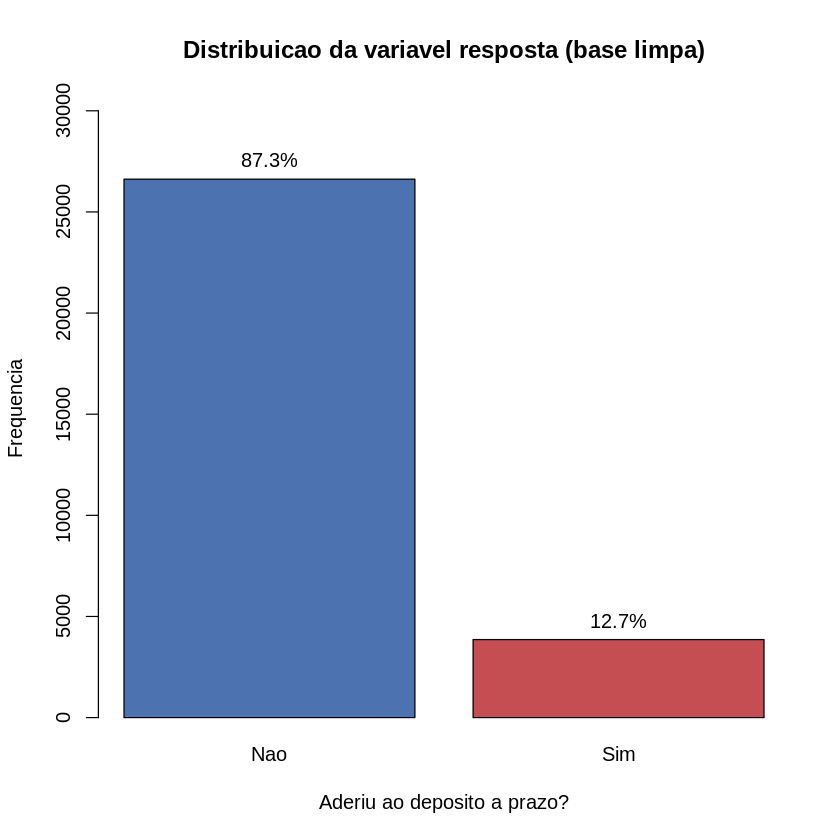

In [118]:
cat("\n== 2. ANALISE EXPLORATORIA (figuras 01-06) ==\n")

freq_y <- table(dados$y); prop_y <- prop.table(freq_y)
cat("  Distribuicao do alvo:", sprintf("nao=%d (%.1f%%), sim=%d (%.1f%%)\n",
    freq_y["no"], 100*prop_y["no"], freq_y["yes"], 100*prop_y["yes"]))
cat("  Razao de desbalanceamento (nao:sim) =", round(freq_y["no"]/freq_y["yes"], 2), ":1\n")

# Fig 01 - distribuicao da variavel resposta
abrir_fig("01_distribuicao_alvo")
bp <- barplot(freq_y, col = c(COR_NAO, COR_SIM), names.arg = pt_niveis("y", names(freq_y)),
              main = "Distribuicao da variavel resposta (base limpa)",
              ylab = "Frequencia", xlab = "Aderiu ao deposito a prazo?",
              ylim = c(0, max(freq_y) * 1.15))
text(bp, freq_y, labels = paste0(round(100 * prop_y, 1), "%"), pos = 3)
fechar_fig()

**Conclusão:** a classe "Sim" representa apenas ~12,7% das observações (razão de desbalanceamento de aproximadamente 6,9:1). Essa proporção é o fio condutor de todo o projeto: ela torna a acurácia uma métrica enganosa (um classificador que sempre prevê "Não" já acertaria ~87% dos casos) e justifica o uso de recall, precisão e F1 da classe "Sim", além das estratégias de balanceamento aplicadas nas Seções 6 e seguintes.

### 2.2 Valores "desconhecido" (`unknown`) por variável

Antes da limpeza, mede a incidência de `"unknown"` em cada variável categórica da base bruta (Figura 2 do relatório).

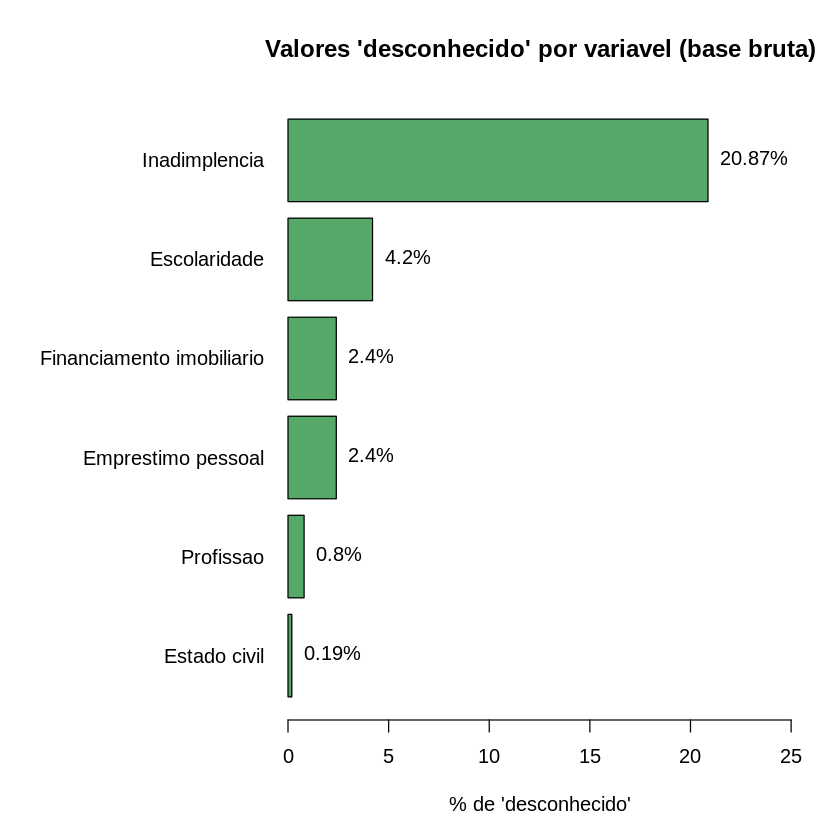

In [119]:
# Fig 02 - valores 'unknown' por variavel (base bruta)
unk <- sapply(bruto, function(x) if (is.character(x)) sum(x == "unknown") else 0L)
unk <- sort(unk[unk > 0], decreasing = TRUE)
pct_unk <- round(100 * unk / nrow(bruto), 2)
abrir_fig("02_valores_unknown")
par(mar = c(5, 12, 4, 2))
bp <- barplot(rev(pct_unk), horiz = TRUE, las = 1, names.arg = rev(pt_var(names(unk))),
              col = COR_NEU, main = "Valores 'desconhecido' por variavel (base bruta)",
              xlab = "% de 'desconhecido'", xlim = c(0, max(pct_unk) * 1.2))
text(rev(pct_unk), bp, labels = paste0(rev(pct_unk), "%"), pos = 4)
fechar_fig()

**Conclusão:** a variável `default` concentra, isoladamente, a maior fração de valores desconhecidos (cerca de 20,9%), muito acima das demais (`education` ~4,2%, `housing`/`loan` ~2,4%). Isso confirma que ela é a principal responsável pela perda de ~26% das observações na etapa de limpeza, e justifica a documentação explícita dessa decisão de pré-processamento.

### 2.3 Variáveis numéricas — histogramas

Desenha o histograma de cada uma das 10 variáveis numéricas (Figura 2/3 do relatório, painel `03_histogramas_numericas`).

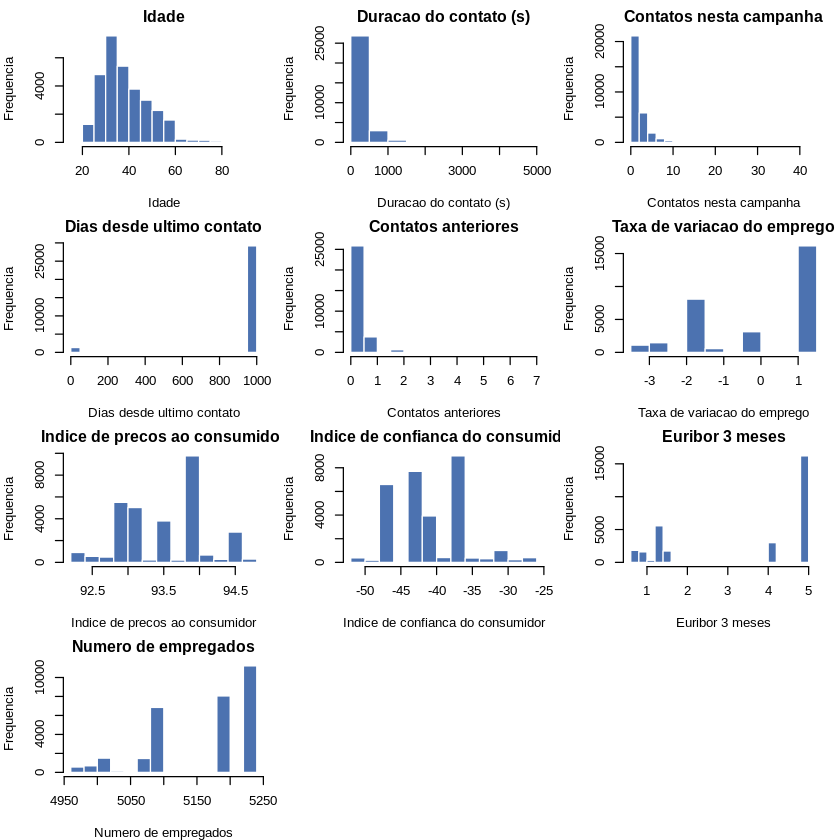

In [120]:
# Fig 03 - histogramas das numericas
abrir_fig("03_histogramas_numericas", largura = 1300, altura = 1000, res = 120)
par(mfrow = c(4, 3), mar = c(4, 4, 2, 1))
for (v in VARS_NUM) hist(dados[[v]], col = COR_NAO, border = "white",
                         main = pt_var(v), xlab = pt_var(v), ylab = "Frequencia")
plot.new(); fechar_fig()

**Conclusão:** as distribuições são predominantemente assimétricas. `age` tem assimetria positiva moderada (cauda à direita, concentração entre 30–45 anos); `campaign` e `previous` são fortemente assimétricas à direita (a maioria dos clientes recebe 1–2 contatos); `pdays` é dominada pelo valor sentinela 999 (~96% dos casos), o que motiva sua recodificação em variável binária (`contatado_antes`) na Seção 3; e os indicadores macroeconômicos não seguem uma forma em sino — são multimodais, refletindo sua natureza de séries medidas em base mensal/trimestral. Esse predomínio de variáveis assimétricas reforça a necessidade de padronização para a Regressão Logística (que se apoia na descida do gradiente), enquanto a Random Forest é invariante a transformações monotônicas de escala.

### 2.4 Variáveis numéricas por classe do alvo (boxplots)

Compara a distribuição de cada variável numérica entre os clientes que aderiram ("Sim") e os que não aderiram ("Não") (Figura 3 do relatório).

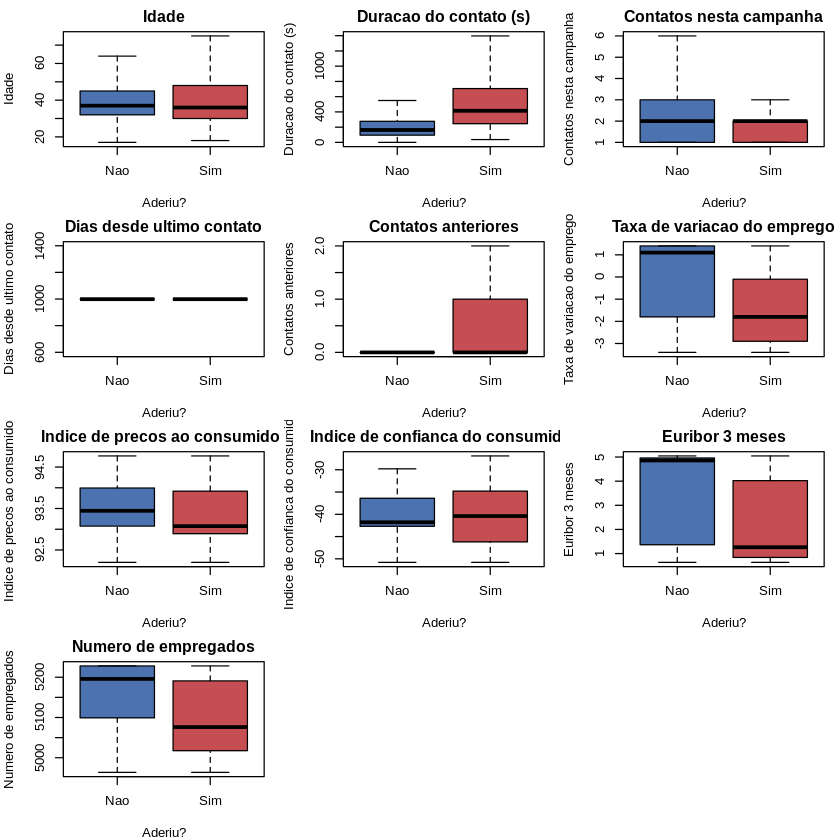

In [121]:
# Fig 04 - boxplots das numericas por classe do alvo
abrir_fig("04_boxplots_por_alvo", largura = 1300, altura = 1000, res = 120)
par(mfrow = c(4, 3), mar = c(4, 4, 2, 1))
for (v in VARS_NUM)
  boxplot(dados[[v]] ~ factor(dados$y, levels = c("no","yes")),
          col = c(COR_NAO, COR_SIM), names = c("Nao","Sim"),
          main = pt_var(v), xlab = "Aderiu?", ylab = pt_var(v), outline = FALSE)
plot.new(); fechar_fig()

**Conclusão:** os indicadores macroeconômicos (`emp.var.rate`, `euribor3m`, `nr.employed`) e `previous`/`campaign` mostram as diferenças mais visíveis entre as classes — clientes que aderem tendem a ser contatados em períodos de cenário econômico mais favorável (taxas mais baixas) e já contatados anteriormente com sucesso. `age` mostra diferença discreta entre as classes, sugerindo associação marginal mais fraca, o que é confirmado depois pelo ranking de correlação (Seção 4).

### 2.5 Taxa de adesão por categoria

Para um conjunto de variáveis categóricas-chave (`poutcome`, `contact`, `month`, `job`, `education`, `default`), calcula a taxa de adesão (`P(y="sim")`) em cada nível, comparando-a com a taxa global (linha tracejada) (Figura 4 do relatório).

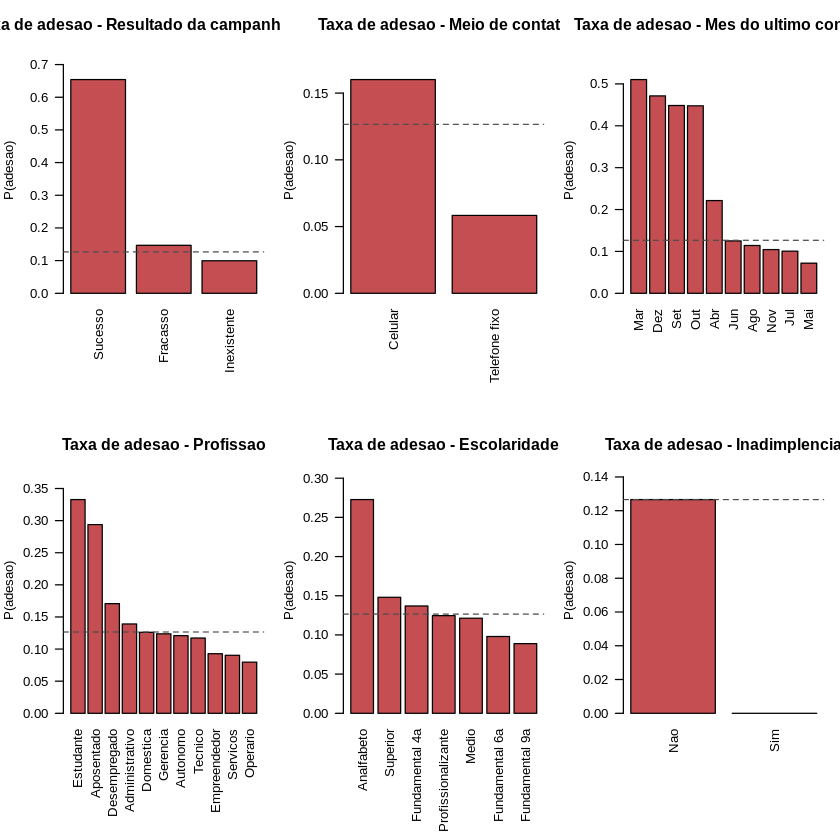

In [122]:
# Fig 05 - taxa de adesao por categoria
taxa_yes <- function(var) {
  tb <- tapply(dados$y == "yes", dados[[var]], mean)
  data.frame(nivel = names(tb), nivel_pt = pt_niveis(var, names(tb)),
             taxa = as.numeric(tb), row.names = NULL)
}
base_rate <- mean(dados$y == "yes")
vars_chave <- c("poutcome", "contact", "month", "job", "education", "default")
abrir_fig("05_taxa_adesao_categoricas", largura = 1300, altura = 1000, res = 120)
par(mfrow = c(2, 3), mar = c(8, 4, 3, 1))
for (v in vars_chave) {
  ty <- taxa_yes(v); ty <- ty[order(-ty$taxa), ]
  barplot(ty$taxa, names.arg = ty$nivel_pt, las = 2, col = COR_SIM,
          main = paste("Taxa de adesao -", pt_var(v)), ylab = "P(adesao)",
          ylim = c(0, max(ty$taxa) * 1.15))
  abline(h = base_rate, lty = 2, col = "gray30")
}
fechar_fig()

**Conclusão:** destacam-se como preditores associados a maior adesão: resultado da campanha anterior igual a "Sucesso" (taxa muito acima da média), contato por celular (vs. telefone fixo), os meses de março, dezembro, setembro e outubro, e os perfis de estudante e aposentado. Esses sinais reaparecem de forma consistente na seleção de variáveis (Seção 4) e nas importâncias estimadas pelos dois modelos (Seções 5–7), o que reforça a coerência da análise exploratória com os resultados de modelagem.

### 2.6 Correlação entre variáveis numéricas (multicolinearidade)

Calcula e visualiza a matriz de correlação de Pearson entre as 10 variáveis numéricas (Figura 5 do relatório).

  Figuras 01-06 exibidas no painel Plots.


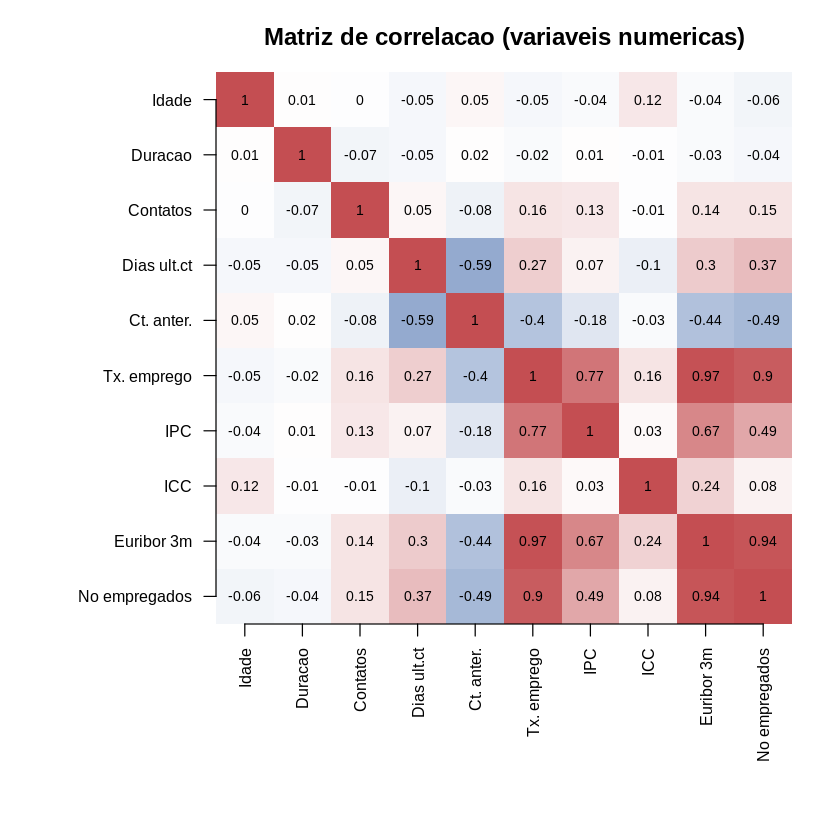

In [123]:
# Fig 06 - correlacao entre as numericas
M <- cor(dados[VARS_NUM]); nv <- length(VARS_NUM); rot <- pt_var_curto(VARS_NUM)
abrir_fig("06_correlacao_numericas", largura = 1050, altura = 1000, res = 120)
par(mar = c(9, 9, 3, 2))
cores <- colorRampPalette(c(COR_NAO, "white", COR_SIM))(100)
image(1:nv, 1:nv, t(M[nv:1, ]), col = cores, zlim = c(-1, 1), axes = FALSE,
      xlab = "", ylab = "", main = "Matriz de correlacao (variaveis numericas)")
axis(1, at = 1:nv, labels = rot, las = 2, cex.axis = 0.8)
axis(2, at = 1:nv, labels = rev(rot), las = 1, cex.axis = 0.8)
for (i in 1:nv) for (j in 1:nv) text(j, nv - i + 1, round(M[i, j], 2), cex = 0.7)
fechar_fig()
if (isTRUE(MOSTRAR_PLOTS)) cat("  Figuras 01-06 exibidas no painel Plots.\n") else
  cat("  Figuras 01-06 salvas em", FIG_DIR, "\n")

**Conclusão:** os indicadores macroeconômicos são fortemente correlacionados entre si — `euribor3m`, `emp.var.rate` e `nr.employed` apresentam `|r|` em torno de 0,9 ou superior. Essa redundância é exatamente o tipo de problema que distorce os coeficientes de um modelo linear (Seção 5.1 mostra um sinal de inversão de sinal causado por essa colinearidade) e motiva a etapa de seleção de variáveis por correlação detalhada na Seção 4, que retém apenas um representante de cada grupo redundante.

## 3. Pré-processamento dos dados

Aplica as transformações sobre a base limpa, todas em base R:

1. Descarte de `duration` (vazamento de informação — só é conhecida depois da ligação);
2. Recodificação do valor sentinela `pdays = 999` na variável binária `contatado_antes`;
3. Codificação *one-hot* das categóricas (56 colunas numéricas resultantes);
4. Particionamento estratificado 70/30 (preservando a proporção de classes);
5. Padronização z-score, com média e desvio estimados **apenas no treino** e aplicados ao teste — evitando vazamento de informação entre os conjuntos.

A padronização $z$-score usa média e desvio estimados **só no treino**, aplicados a treino e teste:

$$z = \frac{x-\mu_{\text{treino}}}{\sigma_{\text{treino}}}$$

In [124]:
# 3. Transformacao: descarta vazamento, recodifica pdays, one-hot, split e padronizacao
cat("\n== 3. TRANSFORMACAO DOS DADOS ==\n")
dados <- dados[, !(names(dados) %in% VARS_LEAKAGE)]
dados$contatado_antes <- as.integer(dados$pdays != 999)
dados$pdays <- NULL
y <- factor(dados$y, levels = c("no", "yes")); dados$y <- NULL
num_keep <- c(setdiff(VARS_NUM, c(VARS_LEAKAGE, "pdays")), "contatado_antes")
cat_keep <- VARS_CAT

X <- construir_design(dados, num_keep, cat_keep)
set.seed(SEED)
idx_tr <- indices_treino_estratificado(y, prop = 0.70)
idx_te <- setdiff(seq_len(nrow(X)), idx_tr)
par_pad     <- padronizar_ajuste(X[idx_tr, , drop = FALSE])
X_treino_z  <- padronizar_aplicar(X[idx_tr, , drop = FALSE], par_pad)
X_teste_z   <- padronizar_aplicar(X[idx_te, , drop = FALSE], par_pad)
y_treino <- y[idx_tr]; y_teste <- y[idx_te]
y_treino01 <- as.integer(y_treino == "yes")
cat(sprintf("  one-hot: %d colunas | treino %d / teste %d | prop 'sim' treino %.4f\n",
            ncol(X), length(idx_tr), length(idx_te), mean(y_treino01)))


== 3. TRANSFORMACAO DOS DADOS ==
  one-hot: 56 colunas | treino 21334 / teste 9144 | prop 'sim' treino 0.1266


**Conclusão:** o resultado é um conjunto de treino com 21.334 observações e um conjunto de teste com 9.144 observações, ambos preservando a proporção real de ~12,7% de "Sim". O conjunto de teste permanece intocado a partir deste ponto — só será usado uma única vez, na avaliação final (Seção 10).

## 4. Seleção de variáveis por correlação (filtro)

Quantifica a associação marginal de cada uma das 56 colunas com o alvo via correlação de Pearson (equivalente ao coeficiente ponto-bisserial para numéricas), seleciona as colunas com `|r| >= 0,05` (limiar de relevância) e, em seguida, remove variáveis redundantes entre si (`|r| > 0,80`, limiar de redundância) usando a reimplementação de `findCorrelation()` da Seção 0.5. O procedimento é conduzido **apenas no treino**.


== 4. SELECAO DE VARIAVEIS POR CORRELACAO (3.2.1) - figura 17 ==
  56 colunas -> 22 relevantes (|r|>=0.05) -> 17 finais (|cor|<=0.80)
  selecionadas: nr.employed, poutcome_success, previous, month_oct, month_mar, contact_cellular, cons.price.idx, month_sep, month_may, job_retired, job_student, month_apr, month_dec, campaign, job_blue-collar, cons.conf.idx, age 


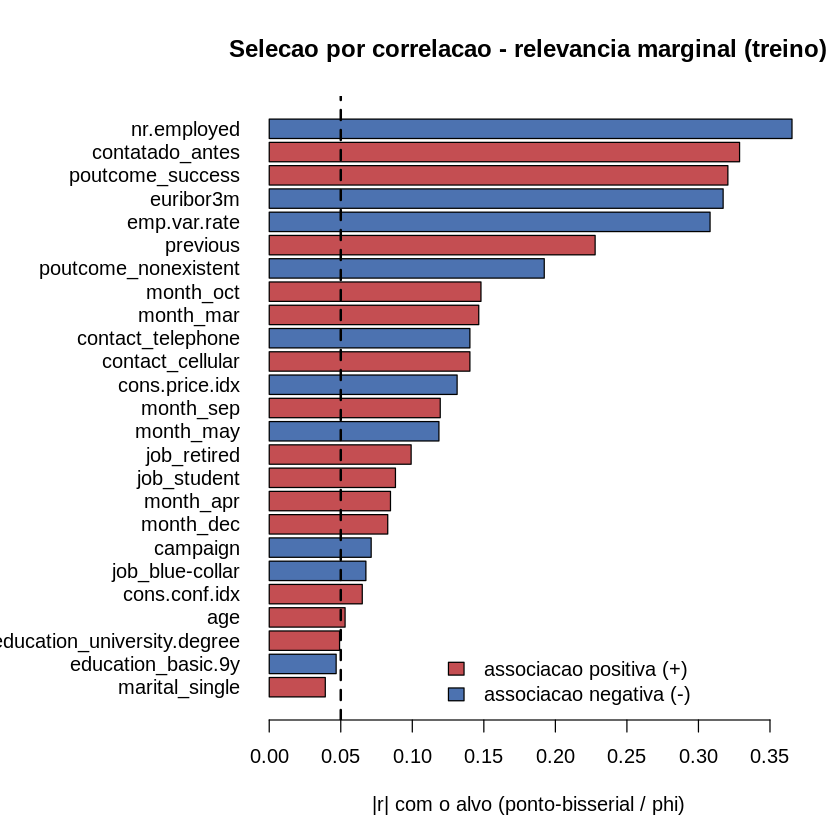

In [125]:
# 4. Selecao por correlacao (so no treino) - figura 17
cat("\n== 4. SELECAO DE VARIAVEIS POR CORRELACAO (3.2.1) - figura 17 ==\n")
TAU <- 0.05; RHO <- 0.80
Xtr_raw <- X[idx_tr, , drop = FALSE]
cor_seguro <- function(xj) if (sd(xj) == 0) 0 else suppressWarnings(cor(xj, y_treino01))
r_alvo <- apply(Xtr_raw, 2, cor_seguro)
ordem <- order(-abs(r_alvo))
sel1 <- colnames(X)[ordem][abs(r_alvo[ordem]) >= TAU]
redund <- if (length(sel1) >= 2)
  sel1[find_correlation(cor(Xtr_raw[, sel1, drop = FALSE]), RHO)] else character(0)
sel_final <- setdiff(sel1, redund)
cat(sprintf("  %d colunas -> %d relevantes (|r|>=%.2f) -> %d finais (|cor|<=%.2f)\n",
            ncol(X), length(sel1), TAU, length(sel_final), RHO))
cat("  selecionadas:", paste(sel_final, collapse = ", "), "\n")

par_sel        <- padronizar_ajuste(X[idx_tr, sel_final, drop = FALSE])
X_treino_sel_z <- padronizar_aplicar(X[idx_tr, sel_final, drop = FALSE], par_sel)
X_teste_sel_z  <- padronizar_aplicar(X[idx_te, sel_final, drop = FALSE], par_sel)

rank_abs <- abs(r_alvo)[ordem]; rank_r <- r_alvo[ordem]; rank_nm <- colnames(X)[ordem]
sel_top <- seq_len(min(25, length(rank_nm)))
o2 <- order(rank_abs[sel_top])
abrir_fig("17_selecao_correlacao", largura = 1100, altura = 950, res = 120)
par(mar = c(5, 11, 4, 2))
cor_barra <- ifelse(rank_r[sel_top][o2] >= 0, COR_SIM, COR_NAO)
barplot(rank_abs[sel_top][o2], horiz = TRUE, names.arg = rank_nm[sel_top][o2], las = 1,
        col = cor_barra, xlab = "|r| com o alvo (ponto-bisserial / phi)",
        main = "Selecao por correlacao - relevancia marginal (treino)")
abline(v = TAU, lty = 2, lwd = 2)
legend("bottomright", fill = c(COR_SIM, COR_NAO),
       legend = c("associacao positiva (+)", "associacao negativa (-)"), bty = "n")
fechar_fig()

**Conclusão:** das 56 colunas originais, 22 passam no critério de relevância e, após a remoção de redundância, restam **17 variáveis finais**. O ranking confirma os sinais da EDA: `nr.employed`, `poutcome_success`, `euribor3m` e `emp.var.rate` lideram a relevância marginal, mas `euribor3m`, `emp.var.rate`, `contatado_antes`, `poutcome_nonexistent` e `contact_telephone` são descartados por redundância com outras variáveis já selecionadas. Esse conjunto reduzido (17 colunas) é o que será comparado ao conjunto completo (56 colunas) na Seção 8.

## 5. Regressão Logística — modelo de referência (baseline)

Monta a matriz de desenho removendo um nível de referência por variável categórica (evitando a armadilha das dummies — colinearidade exata com o intercepto) e ajusta os coeficientes por descida do gradiente em lote (taxa de aprendizado 0,30, critério de convergência: variação do custo abaixo de `1e-07`). Avalia o modelo no próprio treino, com ponto de corte padrão de 0,50.

In [87]:
# 5. Regressao logistica baseline (design completo) - figuras 08-11
cat("\n== 5. REGRESSAO LOGISTICA MANUAL (baseline) - figuras 08-11 ==\n")
des <- montar_design(X_treino_z, cat_keep)
cat("  Removidas", length(des$ref_cols), "categorias de referencia (armadilha dummy).\n")
cat("  Estimando coeficientes por descida do gradiente...\n")
log_base <- ajustar_logistica(des$X, y_treino01, taxa = 0.3, tol = 1e-7, verbose = TRUE)
cat(sprintf("  Convergencia: %d iteracoes | log-loss = %.6f | corte = %.2f\n",
            log_base$iteracoes, log_base$custo_final, log_base$corte))
prob_log <- prever_prob(log_base, des$X)
av_log_base <- avaliar(y_treino, classificar(prob_log))
auc_log <- auc_roc(prob_log, y_treino01)
cat("\n  Matriz de confusao (treino, corte 0,5):\n"); print(av_log_base$matriz)
cat("\n  Metricas (treino):\n"); print(av_log_base$metricas, row.names = FALSE)
cat(sprintf("  AUC (treino) = %.4f\n", auc_log))

coef_tab <- data.frame(variavel = names(log_base$beta),
                       coeficiente = round(as.vector(log_base$beta), 4),
                       razao_chances = round(exp(as.vector(log_base$beta)), 4))
coef_tab <- coef_tab[order(-abs(coef_tab$coeficiente)), ]


== 5. REGRESSAO LOGISTICA MANUAL (baseline) - figuras 08-11 ==
  Removidas 10 categorias de referencia (armadilha dummy).
  Estimando coeficientes por descida do gradiente...
    iter   2000 | custo = 0.295043
    iter   4000 | custo = 0.294446
    iter   6000 | custo = 0.294130
  Convergencia: 6433 iteracoes | log-loss = 0.294083 | corte = 0.50

  Matriz de confusao (treino, corte 0,5):
     Predito
Real     no   yes
  no  18288   346
  yes  2018   682

  Metricas (treino):
                    metrica  valor
                   Acuracia 0.8892
 Sensibilidade (recall sim) 0.2526
             Especificidade 0.9814
             Precisao (sim) 0.6634
                   F1 (sim) 0.3659
  AUC (treino) = 0.8037


**Conclusão:** o ajuste converge em 6.433 iterações, com log-loss final de 0,2941 e AUC de treino de 0,8037 — uma capacidade discriminativa razoável. Entretanto, isso ainda não conta toda a história: a forma como essa probabilidade é convertida em classe (ponto de corte) é o que vai determinar se o modelo é útil para o problema de negócio, como mostram as métricas a seguir.

### 5.1 Convergência da descida do gradiente

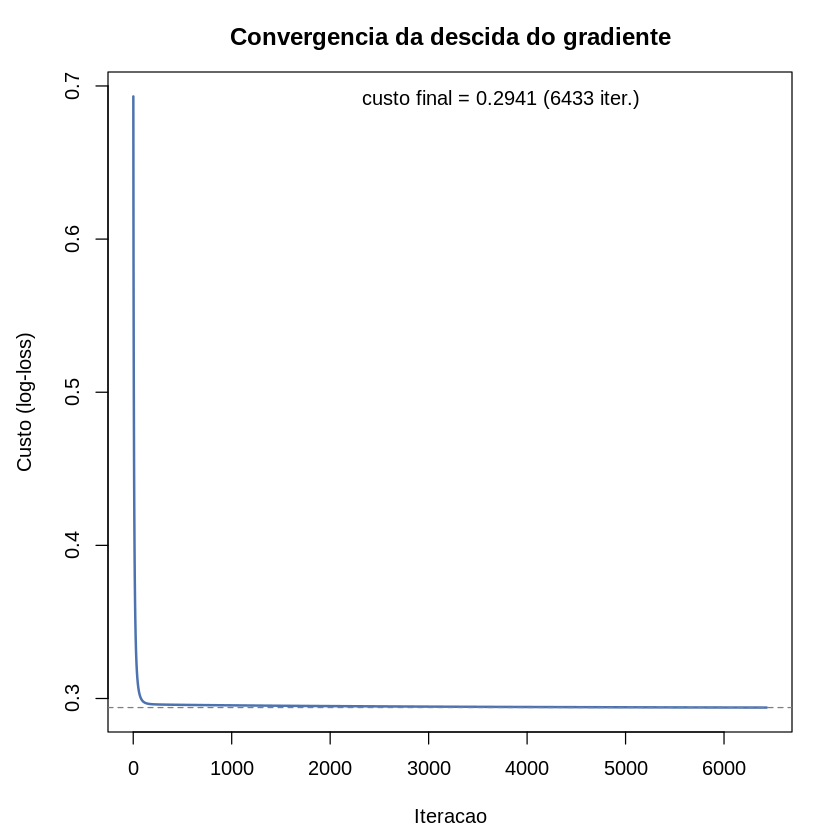

In [88]:
# Fig 08 - convergencia da descida do gradiente
abrir_fig("08_logistica_convergencia", largura = 1000, altura = 650, res = 120)
par(mar = c(4.5, 4.5, 3, 2))
plot(log_base$historico, type = "l", lwd = 2, col = COR_NAO, xlab = "Iteracao",
     ylab = "Custo (log-loss)", main = "Convergencia da descida do gradiente")
abline(h = log_base$custo_final, lty = 2, col = "gray50")
legend("topright", bty = "n",
       legend = sprintf("custo final = %.4f (%d iter.)", log_base$custo_final, log_base$iteracoes))
fechar_fig()

**Conclusão:** a curva de log-loss cai abruptamente nas primeiras iterações e depois se estabiliza em um platô em torno de 0,294 — evidência de que a taxa de aprendizado (0,30) é adequada (sem oscilações) e de que o critério de parada (variação do custo abaixo de `1e-07`) é atingido de forma estável, sem necessidade de intervir no número máximo de iterações.

### 5.2 Importância das variáveis (|coeficiente|, escala padronizada)

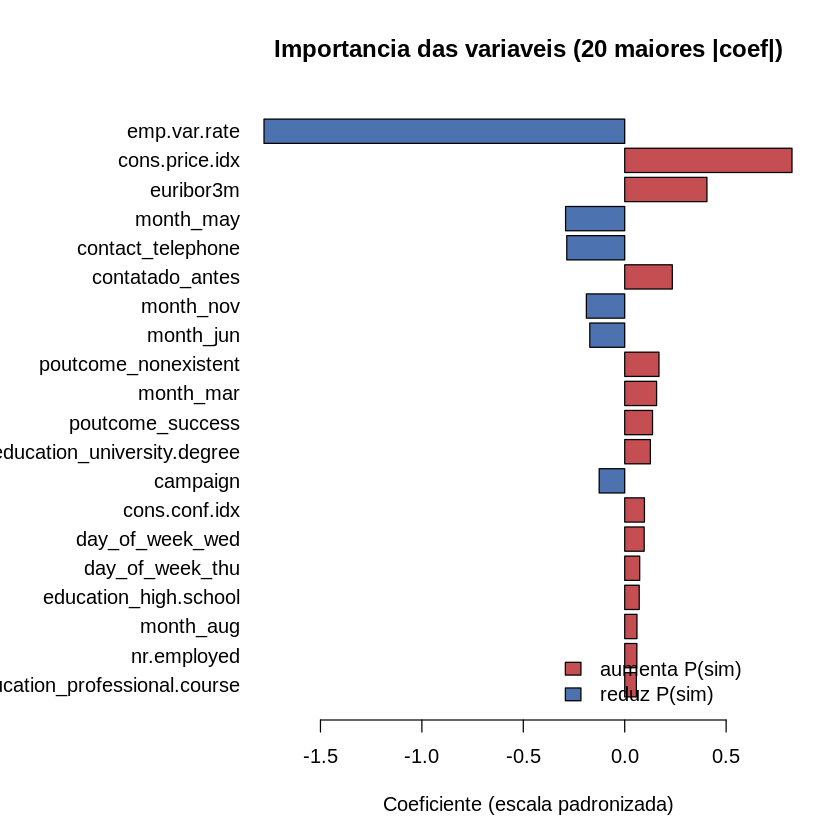

In [89]:
# Fig 09 - importancia por |coef| (20 maiores)
imp_log <- coef_tab[coef_tab$variavel != "(Intercepto)", ]
imp_log <- head(imp_log[order(-abs(imp_log$coeficiente)), ], 20)
imp_log <- imp_log[order(abs(imp_log$coeficiente)), ]
abrir_fig("09_logistica_importancia", largura = 1100, altura = 950, res = 120)
par(mar = c(5, 11, 4, 2))
barplot(imp_log$coeficiente, horiz = TRUE, names.arg = imp_log$variavel, las = 1,
        col = ifelse(imp_log$coeficiente >= 0, COR_SIM, COR_NAO),
        xlab = "Coeficiente (escala padronizada)",
        main = "Importancia das variaveis (20 maiores |coef|)")
legend("bottomright", fill = c(COR_SIM, COR_NAO),
       legend = c("aumenta P(sim)", "reduz P(sim)"), bty = "n")
fechar_fig()

**Conclusão:** observa-se um sinal de multicolinearidade: o coeficiente de `euribor3m` resulta **positivo** (+0,41) no modelo completo, embora sua correlação marginal com o alvo seja **negativa** (-0,32, ver Seção 4). Essa inversão de sinal é característica de preditores fortemente correlacionados entre si (os indicadores macroeconômicos identificados na Seção 2.6) e compromete a interpretação direta dos coeficientes nesta versão de 56 colunas — problema que a seleção por correlação (Seção 4) corrige ao reter apenas um representante de cada grupo redundante (ver Seção 8).

### 5.3 Curva ROC (treino)

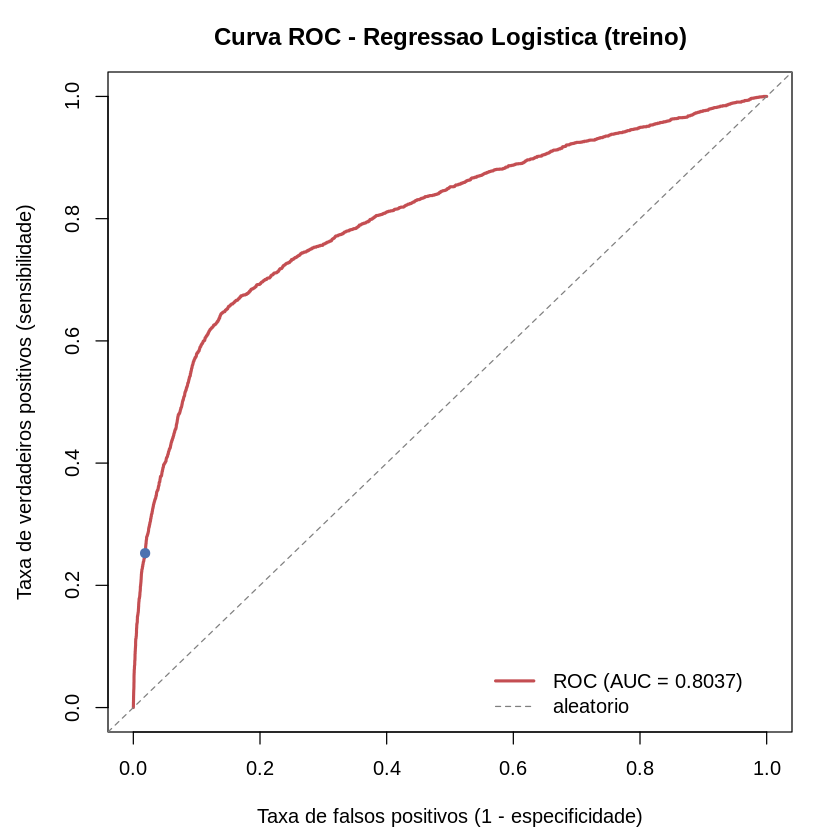

In [90]:
# Fig 10 - curva ROC com o ponto de operacao do corte 0,5
roc_log <- curva_roc(prob_log, y_treino01)
abrir_fig("10_logistica_roc", largura = 800, altura = 750, res = 120)
par(mar = c(4.5, 4.5, 3, 2))
plot(roc_log$taxa_fp, roc_log$taxa_vp, type = "l", lwd = 2.5, col = COR_SIM,
     xlim = c(0, 1), ylim = c(0, 1),
     xlab = "Taxa de falsos positivos (1 - especificidade)",
     ylab = "Taxa de verdadeiros positivos (sensibilidade)",
     main = "Curva ROC - Regressao Logistica (treino)")
abline(0, 1, lty = 2, col = "gray50")
points(1 - av_log_base$metricas$valor[3], av_log_base$metricas$valor[2], pch = 19, col = COR_NAO)
legend("bottomright", bty = "n", lwd = c(2.5, 1), lty = c(1, 2), col = c(COR_SIM, "gray50"),
       legend = c(sprintf("ROC (AUC = %.4f)", auc_log), "aleatorio"))
fechar_fig()

**Conclusão:** o AUC de 0,8037 indica boa capacidade de ranquear corretamente os clientes por probabilidade de adesão, bem acima do classificador aleatório (linha diagonal). O ponto marcado no gráfico corresponde ao corte padrão de 0,50, que — como evidenciado pela matriz de confusão a seguir — está longe do ponto de operação ideal para a classe minoritária.

### 5.4 Matriz de confusão (treino, corte 0,50)

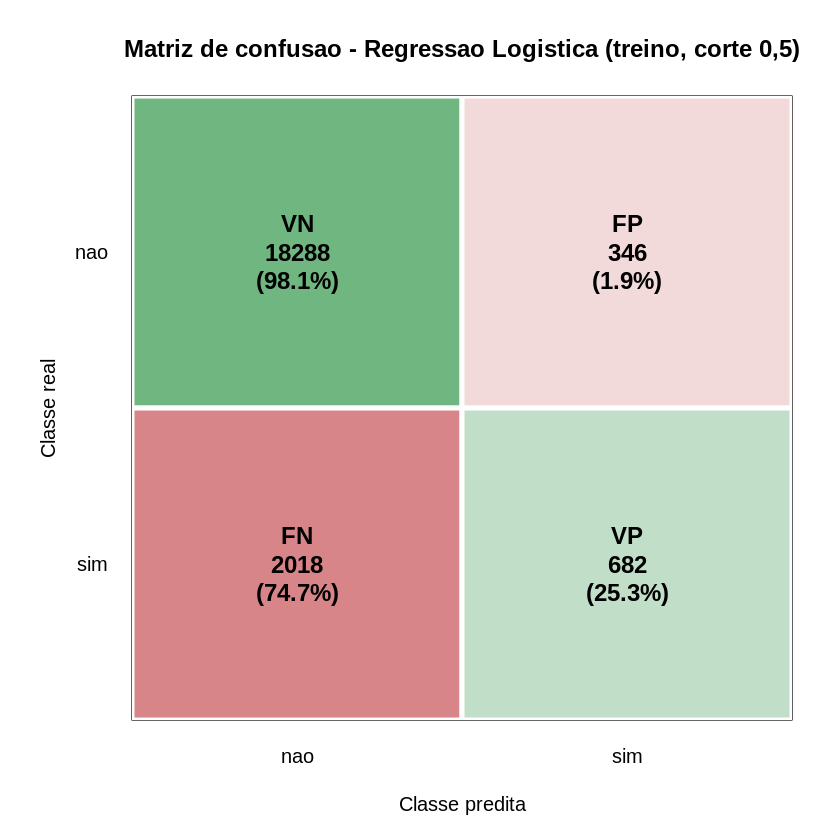

In [91]:
# Fig 11 - matriz de confusao
plot_matriz_confusao(av_log_base$matriz, "11_logistica_matriz_confusao",
                     "Matriz de confusao - Regressao Logistica (treino, corte 0,5)")

**Conclusão:** no modelo de referência, sem qualquer tratamento do desbalanceamento, a acurácia é alta (0,889), mas o **recall da classe "Sim" é de apenas 0,25**: o modelo tende a prever quase sempre "Não", deixando de identificar 3 em cada 4 clientes que de fato adeririam. Esse resultado é a manifestação direta do desbalanceamento da base e motiva diretamente o tratamento descrito nas seções seguintes.

## 6. Tratamento do desbalanceamento — Random Undersampling (2:1) na Regressão Logística

Aplica subamostragem aleatória da classe majoritária **somente no treino**: mantêm-se todos os "Sim" e sorteiam-se, sem reposição, até o dobro desse total de "Não" (razão 2:1). A logística é reajustada sobre esse treino balanceado e avaliada sobre o treino completo (proporção realista de classes), permitindo comparação justa com o modelo de referência da Seção 5.

In [92]:
# 6. Desbalanceamento: random undersampling 2:1 - figuras 12-13
cat("\n== 6. DESBALANCEAMENTO: RANDOM UNDERSAMPLING (2:1) - figuras 12-13 ==\n")
idx_us <- random_undersample(y_treino, razao = 2)
log_us <- ajustar_logistica(des$X[idx_us, , drop = FALSE], y_treino01[idx_us])
av_log_us <- avaliar(y_treino, classificar(prever_prob(log_us, des$X)))
comp_bal <- data.frame(metrica = av_log_base$metricas$metrica,
                       baseline = av_log_base$metricas$valor,
                       undersample = av_log_us$metricas$valor)
comp_bal$diferenca <- round(comp_bal$undersample - comp_bal$baseline, 4)
cat(sprintf("  treino balanceado: %d obs (%.1f%% 'sim')\n",
            length(idx_us), 100 * mean(y_treino01[idx_us])))
cat("\n  Matriz de confusao - undersampling (treino):\n"); print(av_log_us$matriz)
cat("\n  Comparacao baseline x undersampling (treino):\n"); print(comp_bal, row.names = FALSE)


== 6. DESBALANCEAMENTO: RANDOM UNDERSAMPLING (2:1) - figuras 12-13 ==
  treino balanceado: 8100 obs (33.3% 'sim')

  Matriz de confusao - undersampling (treino):
     Predito
Real     no   yes
  no  16727  1907
  yes  1126  1574

  Comparacao baseline x undersampling (treino):
                    metrica baseline undersample diferenca
                   Acuracia   0.8892      0.8578   -0.0314
 Sensibilidade (recall sim)   0.2526      0.5830    0.3304
             Especificidade   0.9814      0.8977   -0.0837
             Precisao (sim)   0.6634      0.4522   -0.2112
                   F1 (sim)   0.3659      0.5093    0.1434


**Conclusão:** o balanceamento eleva o recall da classe "Sim" de 0,25 para 0,58 e o F1 de 0,37 para 0,51; em contrapartida, a precisão recua de 0,66 para 0,45. Trata-se do compromisso esperado entre recall e precisão. Para o objetivo de negócio — evitar a perda de clientes propensos a aderir — a priorização do recall é adequada.

### 6.1 Matriz de confusão e comparação visual (baseline x undersampling)

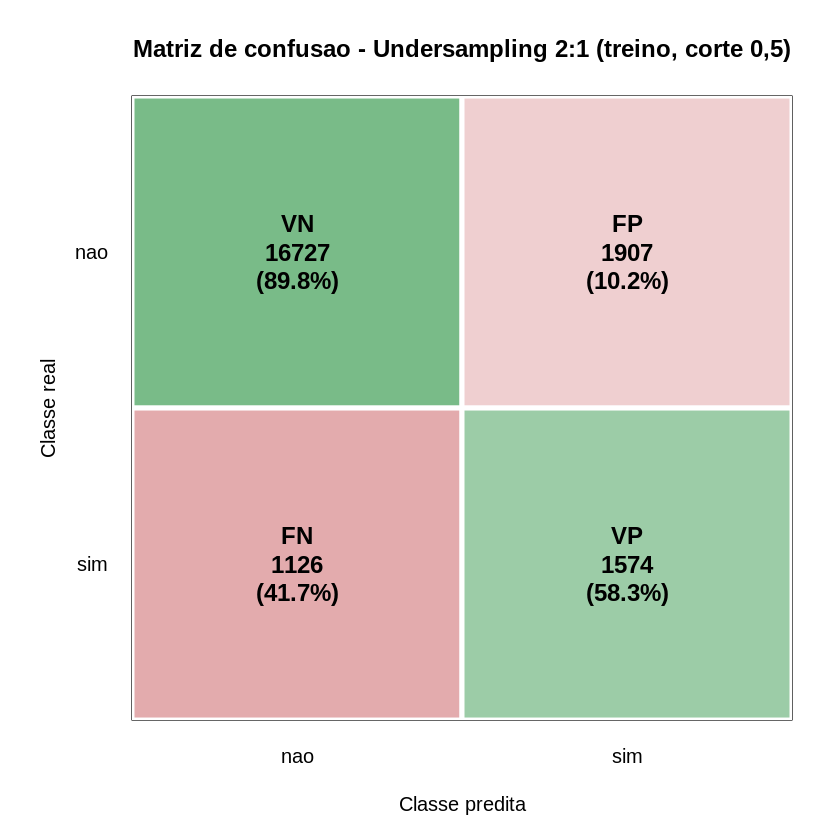

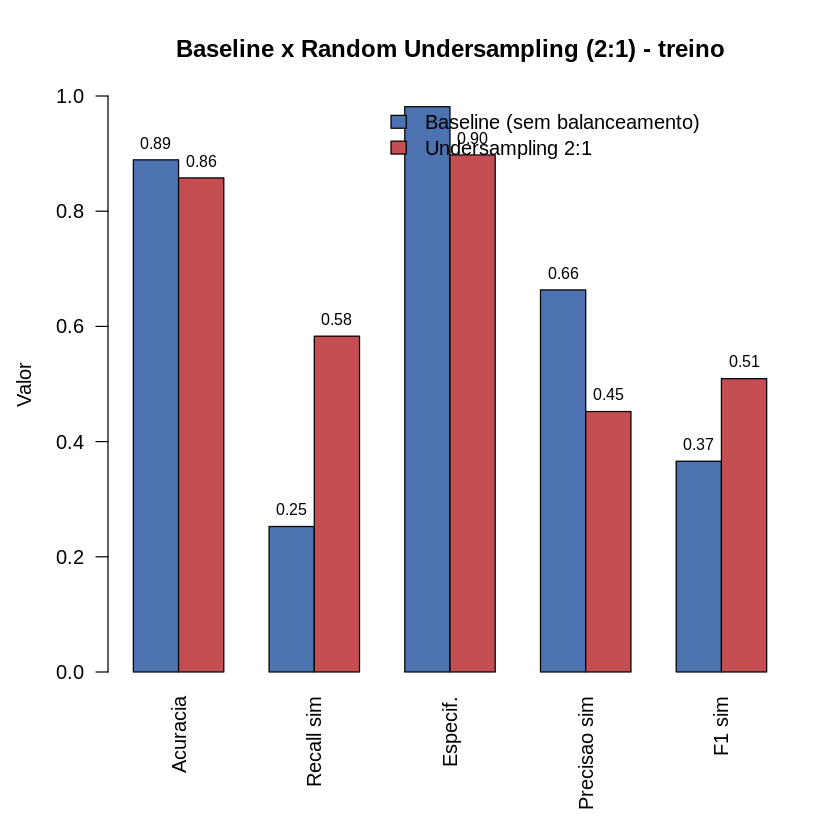

In [93]:
plot_matriz_confusao(av_log_us$matriz, "12_balanceamento_matriz_confusao",
                     "Matriz de confusao - Undersampling 2:1 (treino, corte 0,5)")
m_bal <- t(as.matrix(comp_bal[, c("baseline", "undersample")]))
abrir_fig("13_balanceamento_comparacao", largura = 1100, altura = 750, res = 120)
par(mar = c(7, 4.5, 4, 2))
bp <- barplot(m_bal, beside = TRUE, col = c(COR_NAO, COR_SIM), ylim = c(0, 1),
              names.arg = c("Acuracia", "Recall sim", "Especif.", "Precisao sim", "F1 sim"),
              ylab = "Valor", las = 2, main = "Baseline x Random Undersampling (2:1) - treino")
text(bp, m_bal + 0.03, labels = sprintf("%.2f", m_bal), cex = 0.8)
legend("topright", fill = c(COR_NAO, COR_SIM), bty = "n",
       legend = c("Baseline (sem balanceamento)", "Undersampling 2:1"))
fechar_fig()

**Conclusão:** o gráfico de barras evidencia visualmente o trade-off: o recall (classe "Sim") quase dobra com o undersampling, enquanto a especificidade e a precisão recuam moderadamente. A acurácia, por ser dominada pela classe majoritária, varia pouco — outra confirmação de que essa métrica isolada não é adequada para guiar a escolha do modelo neste problema.

## 7. Random Forest manual (Balanced Random Forest, avaliação OOB)

Treina 60 árvores CART sobre o conjunto completo de 56 colunas, cada uma a partir de um bootstrap balanceado (razão 2:1) e de um subconjunto aleatório de variáveis por nó (`mtry`). A avaliação é feita por *Out-of-Bag* (OOB): cada observação é prevista apenas pelas árvores que não a utilizaram no treino, fornecendo uma estimativa honesta de generalização sem usar o conjunto de teste.

In [94]:
# 7. Random forest (design completo, avaliacao OOB) - figuras 14-16
cat("\n== 7. RANDOM FOREST MANUAL (Balanced RF, OOB) - figuras 14-16 ==\n")
cat("  Treinando 60 arvores (bootstrap balanceado 2:1)...\n")
rf_full <- treinar_floresta(X_treino_z, y_treino01, n_arvores = 60, max_prof = 12,
                            min_no = 40, n_cortes = 12, razao_bb = 2, verbose = TRUE)
ok <- rf_full$oob_cont > 0
av_rf <- avaliar(y_treino[ok], classificar(rf_full$oob_prob[ok]))
auc_rf_oob <- auc_roc(rf_full$oob_prob[ok], y_treino01[ok])
cat(sprintf("  mtry = %d | AUC (OOB) = %.4f\n", rf_full$params$mtry, auc_rf_oob))
cat("\n  Matriz de confusao - RF (OOB):\n"); print(av_rf$matriz)
cat("\n  Metricas - RF (OOB):\n"); print(av_rf$metricas, row.names = FALSE)

imp_rf <- importancia_floresta(rf_full, colnames(X_treino_z))
imp_rf_tab <- data.frame(variavel = names(imp_rf), importancia = round(as.vector(imp_rf), 5))
cat("\n  Importancia por reducao de Gini (10 maiores):\n")
print(head(imp_rf_tab, 10), row.names = FALSE)

comp_mod <- data.frame(metrica = av_log_base$metricas$metrica,
                       logistica_baseline = av_log_base$metricas$valor,
                       logistica_under    = av_log_us$metricas$valor,
                       rf_oob             = av_rf$metricas$valor)
cat("\n  Comparacao de modelos:\n"); print(comp_mod, row.names = FALSE)


== 7. RANDOM FOREST MANUAL (Balanced RF, OOB) - figuras 14-16 ==
  Treinando 60 arvores (bootstrap balanceado 2:1)...
    arvore 20 / 60 
    arvore 40 / 60 
    arvore 60 / 60 
  mtry = 7 | AUC (OOB) = 0.8051

  Matriz de confusao - RF (OOB):
     Predito
Real     no   yes
  no  16671  1963
  yes  1064  1636

  Metricas - RF (OOB):
                    metrica  valor
                   Acuracia 0.8581
 Sensibilidade (recall sim) 0.6059
             Especificidade 0.8947
             Precisao (sim) 0.4546
                   F1 (sim) 0.5194

  Importancia por reducao de Gini (10 maiores):
         variavel importancia
      nr.employed     0.17734
        euribor3m     0.13849
     emp.var.rate     0.12801
    cons.conf.idx     0.07871
 poutcome_success     0.05142
   cons.price.idx     0.04500
  contatado_antes     0.04078
              age     0.02863
         previous     0.02725
        month_may     0.02325

  Comparacao de modelos:
                    metrica logistica_baseline lo

**Conclusão:** com AUC (OOB) de 0,8051 — comparável ao da logística — a Random Forest já no design completo apresenta recall de 0,61 e F1 de 0,52, superando a logística com undersampling (recall 0,58, F1 0,51) mesmo sob uma avaliação mais rigorosa (OOB em vez de resubstituição no treino). As variáveis mais importantes por redução de Gini (`nr.employed`, `euribor3m`, `emp.var.rate`, `cons.conf.idx`, `poutcome_success`) coincidem com os sinais já identificados na EDA, reforçando a coerência da análise.

### 7.1 Matriz de confusão (OOB)

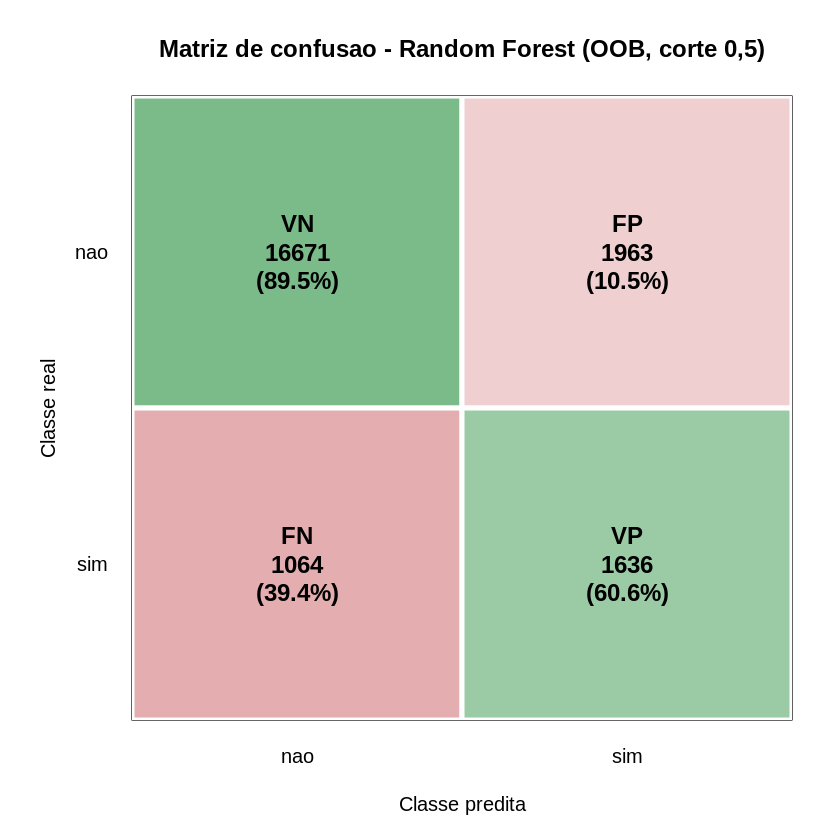

In [95]:
plot_matriz_confusao(av_rf$matriz, "14_rf_matriz_confusao_oob",
                     "Matriz de confusao - Random Forest (OOB, corte 0,5)")

**Conclusão:** comparada à matriz da logística baseline (Seção 5.4), a Random Forest troca parte da especificidade (0,89 vs. 0,98) por um recall muito superior (0,61 vs. 0,25) — exatamente o compromisso desejado para um problema em que identificar os clientes propensos a aderir vale mais do que evitar todo falso positivo.

### 7.2 Importância das variáveis (redução de Gini)

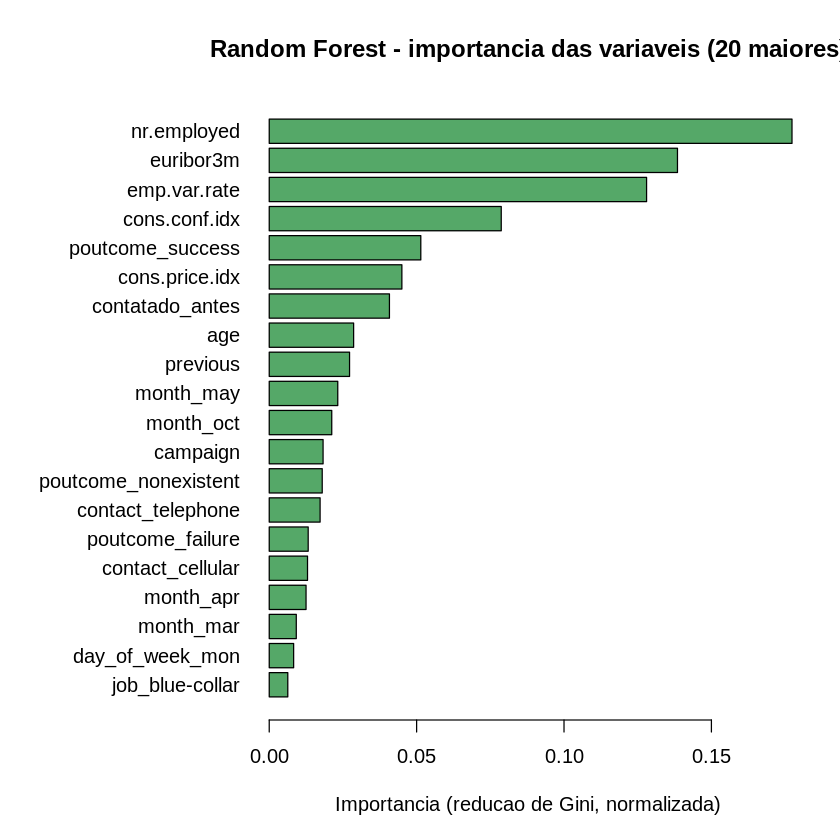

In [96]:
top_rf <- head(imp_rf_tab, 20); top_rf <- top_rf[order(top_rf$importancia), ]
abrir_fig("15_rf_importancia", largura = 1100, altura = 950, res = 120)
par(mar = c(5, 11, 4, 2))
barplot(top_rf$importancia, horiz = TRUE, names.arg = top_rf$variavel, las = 1, col = COR_NEU,
        xlab = "Importancia (reducao de Gini, normalizada)",
        main = "Random Forest - importancia das variaveis (20 maiores)")
fechar_fig()

**Conclusão:** ao contrário da logística (Seção 5.2), aqui não há inversão de sinal — a importância por redução de Gini é, por natureza, invariante à multicolinearidade entre preditores e à escala das variáveis. Os indicadores macroeconômicos dominam o ranking, seguidos do resultado da campanha anterior (`poutcome_success`) e da variável `contatado_antes`, todos sinais já visíveis na análise exploratória.

### 7.3 Comparação entre os três modelos até aqui

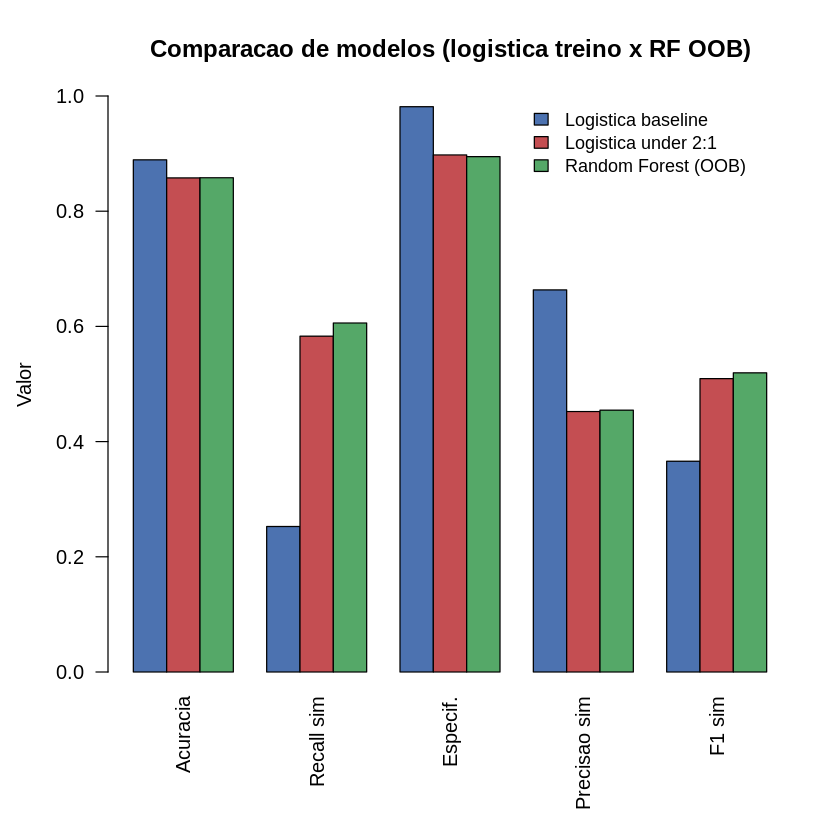

In [97]:
m_mod <- t(as.matrix(comp_mod[, c("logistica_baseline", "logistica_under", "rf_oob")]))
abrir_fig("16_comparacao_modelos", largura = 1200, altura = 760, res = 120)
par(mar = c(7, 4.5, 4, 2))
barplot(m_mod, beside = TRUE, col = c(COR_NAO, COR_SIM, COR_NEU), ylim = c(0, 1),
        names.arg = c("Acuracia", "Recall sim", "Especif.", "Precisao sim", "F1 sim"),
        ylab = "Valor", las = 2, main = "Comparacao de modelos (logistica treino x RF OOB)")
legend("topright", fill = c(COR_NAO, COR_SIM, COR_NEU), bty = "n", cex = 0.9,
       legend = c("Logistica baseline", "Logistica under 2:1", "Random Forest (OOB)"))
fechar_fig()

**Conclusão:** considerando as métricas adequadas ao desbalanceamento, a Random Forest apresenta o melhor compromisso entre recall e precisão (F1 0,52), seguida de perto pela logística com undersampling (F1 0,51) e, bem atrás, pela logística baseline (F1 0,37). Essa comparação preliminar já aponta a Random Forest como candidata a modelo final — decisão consolidada nas seções seguintes.

## 8. Impacto da seleção de variáveis sobre os modelos

Reaplica os três experimentos (logística baseline, logística com undersampling e Random Forest) sobre o conjunto de 17 variáveis selecionadas na Seção 4, comparando com a versão de 56 colunas usada até aqui.

In [98]:
# 8. Impacto da selecao sobre os modelos - figura 18
cat("\n== 8. IMPACTO DA SELECAO (17 colunas x 56 colunas) - figura 18 ==\n")
fit_log_sel <- function(Xz, yb) ajustar_logistica(cbind(`(Intercepto)` = 1, Xz), yb)
metr_log_sel <- function(mod, Xz, real)
  avaliar(real, classificar(prever_prob(mod, cbind(`(Intercepto)` = 1, Xz))))$metricas$valor

log_base_sel <- fit_log_sel(X_treino_sel_z, y_treino01)
met_base_sel <- metr_log_sel(log_base_sel, X_treino_sel_z, y_treino)
log_us_sel   <- fit_log_sel(X_treino_sel_z[idx_us, , drop = FALSE], y_treino01[idx_us])
met_us_sel   <- metr_log_sel(log_us_sel, X_treino_sel_z, y_treino)
rf_sel <- treinar_floresta(X_treino_sel_z, y_treino01, n_arvores = 60, max_prof = 12,
                           min_no = 40, n_cortes = 12, razao_bb = 2)
ok_sel <- rf_sel$oob_cont > 0
met_rf_sel <- avaliar(y_treino[ok_sel], classificar(rf_sel$oob_prob[ok_sel]))$metricas$valor

comp_sel <- data.frame(
  metrica = av_log_base$metricas$metrica,
  log_baseline_56col = av_log_base$metricas$valor, log_baseline_sel = round(met_base_sel, 4),
  log_under_56col = av_log_us$metricas$valor,      log_under_sel = round(met_us_sel, 4),
  rf_56col_oob = av_rf$metricas$valor,             rf_sel_oob = round(met_rf_sel, 4))
cat("  Comparacao 56 colunas x selecao (", length(sel_final), "colunas):\n")
print(comp_sel, row.names = FALSE)


== 8. IMPACTO DA SELECAO (17 colunas x 56 colunas) - figura 18 ==
  Comparacao 56 colunas x selecao ( 17 colunas):
                    metrica log_baseline_56col log_baseline_sel log_under_56col
                   Acuracia             0.8892           0.8881          0.8578
 Sensibilidade (recall sim)             0.2526           0.2311          0.5830
             Especificidade             0.9814           0.9833          0.8977
             Precisao (sim)             0.6634           0.6667          0.4522
                   F1 (sim)             0.3659           0.3432          0.5093
 log_under_sel rf_56col_oob rf_sel_oob
        0.8598       0.8581     0.8608
        0.5274       0.6059     0.5926
        0.9080       0.8947     0.8997
        0.4536       0.4546     0.4612
        0.4878       0.5194     0.5187


**Conclusão:** a Random Forest preserva o desempenho (F1 em torno de 0,519 em ambas as versões) usando cerca de um terço das variáveis — evidência de robustez a variáveis irrelevantes/redundantes. Já a logística sofre uma pequena perda de recall e F1 com a seleção (de 0,58 para 0,53 no recall, undersampling), pois o filtro de correlação avalia cada preditor isoladamente e ignora interações entre variáveis que a regressão completa, ainda que de forma ruidosa, conseguia captar parcialmente. Em compensação, a logística torna-se muito mais rápida de treinar (a Seção 8.1 confirma a redução de 6.433 para 383 iterações).

### 8.1 Comparação visual — recall e F1 (classe "Sim")

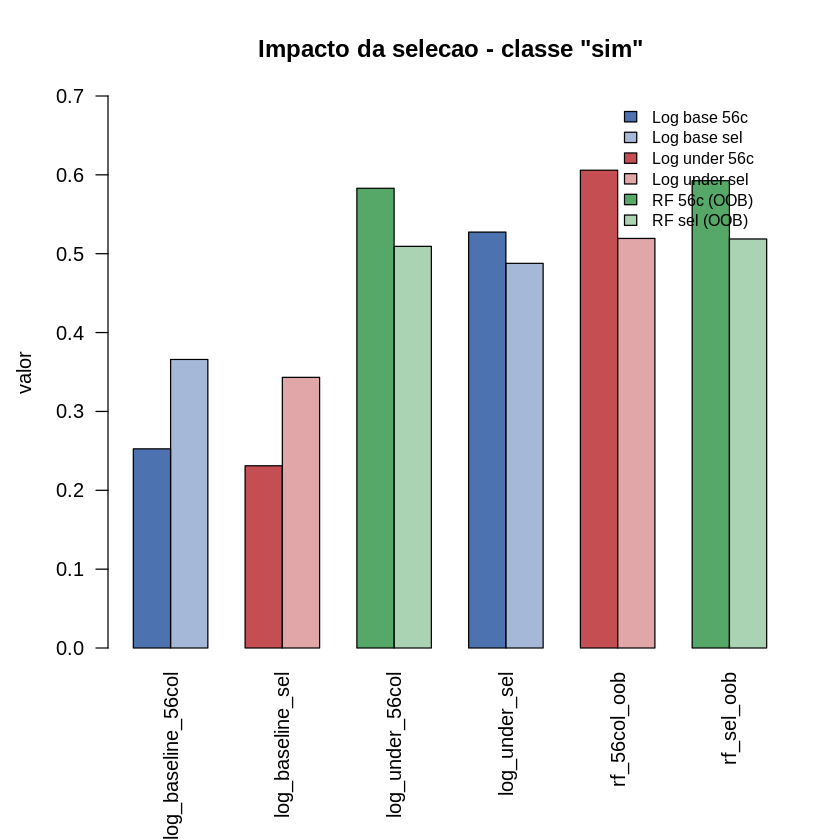

In [99]:
linhas_chave <- comp_sel$metrica %in% c("Sensibilidade (recall sim)", "F1 (sim)")
Mimp <- as.matrix(comp_sel[linhas_chave,
                  c("log_baseline_56col","log_baseline_sel","log_under_56col",
                    "log_under_sel","rf_56col_oob","rf_sel_oob")])
rownames(Mimp) <- c("Recall (sim)", "F1 (sim)")
abrir_fig("18_selecao_impacto_modelos", largura = 1200, altura = 750, res = 120)
par(mar = c(8, 4.5, 4, 2))
cores6 <- c(COR_NAO, adjustcolor(COR_NAO,0.5), COR_SIM, adjustcolor(COR_SIM,0.5),
            COR_NEU, adjustcolor(COR_NEU,0.5))
barplot(Mimp, beside = TRUE, col = cores6, ylim = c(0, 0.7), las = 2,
        ylab = "valor", main = "Impacto da selecao - classe \"sim\"")
legend("topright", bty = "n", fill = cores6, cex = 0.8,
       legend = c("Log base 56c","Log base sel","Log under 56c","Log under sel",
                  "RF 56c (OOB)","RF sel (OOB)"))
fechar_fig()

**Conclusão:** o gráfico confirma numericamente o texto acima: as barras da Random Forest (verdes) praticamente não se alteram entre a versão de 56 colunas e a versão selecionada, enquanto as barras da logística (azul/vermelho) mostram uma queda visível, mais acentuada no recall do que no F1. Isso reforça a recomendação de usar o conjunto de 17 variáveis como pipeline padrão — mais simples e rápido, sem custo para o modelo que efetivamente será levado à avaliação final.

## 9. Tuning da Random Forest por Otimização Bayesiana (manual)

A Random Forest é o modelo levado à avaliação final, o que justifica concentrar nele o procedimento mais sofisticado de ajuste de hiperparâmetros. Sobre uma subamostra estratificada de 8.000 observações do treino (por viabilidade computacional), conduz-se uma validação cruzada k-fold (k = 4) estratificada cuja métrica objetivo é o **F1 da classe "Sim"** — e não a acurácia, devido ao desbalanceamento. A otimização bayesiana (Processo Gaussiano + Expected Improvement, Seção 0.6) busca, em um orçamento de 6 avaliações iniciais + 14 iterações, a melhor combinação de `mtry`, profundidade máxima e mínimo de observações por nó.

In [100]:
# 9. Tuning da random forest por otimizacao bayesiana (sobre a selecao) - figuras 19-20
cat("\n== 9. TUNING (OTIMIZACAO BAYESIANA, F1 por CV 4-fold) - figuras 19-20 ==\n")
idx_sub <- subamostra_estratificada(y_treino01, 8000)
Xs <- X_treino_sel_z[idx_sub, , drop = FALSE]; y01s <- y_treino01[idx_sub]
yfs <- factor(ifelse(y01s == 1, "yes", "no"), levels = c("no", "yes"))
folds <- kfold_estratificado(y01s, k = 4)
objetivo_rf <- function(par) {
  mtry <- max(2, min(ncol(Xs), round(par[1])))
  max_prof <- max(3, round(par[2])); min_no <- max(5, round(par[3]))
  f1 <- numeric(4)
  for (k in 1:4) {
    tr <- which(folds != k); va <- which(folds == k)
    fl <- treinar_floresta(Xs[tr, , drop = FALSE], y01s[tr], n_arvores = 40, mtry = mtry,
                           max_prof = max_prof, min_no = min_no, n_cortes = 8)
    v <- avaliar(yfs[va], classificar(prever_floresta(fl, Xs[va, , drop = FALSE])))$metricas$valor[5]
    f1[k] <- ifelse(is.na(v), 0, v)
  }
  mean(f1)
}
limites <- rbind(mtry = c(2, ncol(Xs)), max_prof = c(4, 20), min_no = c(10, 120))
cat("  Rodando otimizacao bayesiana (6 init + 14 iteracoes)...\n")
res <- otimizacao_bayesiana(objetivo_rf, limites, n_init = 6, n_iter = 14, verbose = TRUE)
mtry_best <- max(2, min(ncol(X_treino_sel_z), round(res$melhor_par["mtry"])))
prof_best <- max(3, round(res$melhor_par["max_prof"]))
no_best   <- max(5, round(res$melhor_par["min_no"]))
cat(sprintf("\n  Melhor configuracao: mtry=%d, max_prof=%d, min_no=%d (F1 CV = %.4f)\n",
            mtry_best, prof_best, no_best, res$melhor_y))


== 9. TUNING (OTIMIZACAO BAYESIANA, F1 por CV 4-fold) - figuras 19-20 ==
  Rodando otimizacao bayesiana (6 init + 14 iteracoes)...
    init 1/6  F1=0.5068
    init 2/6  F1=0.5058
    init 3/6  F1=0.5110
    init 4/6  F1=0.5063
    init 5/6  F1=0.5036
    init 6/6  F1=0.5145
    iter 1/14  F1=0.5085  (melhor=0.5145)
    iter 2/14  F1=0.5069  (melhor=0.5145)
    iter 3/14  F1=0.5096  (melhor=0.5145)
    iter 4/14  F1=0.5118  (melhor=0.5145)
    iter 5/14  F1=0.5048  (melhor=0.5145)
    iter 6/14  F1=0.5093  (melhor=0.5145)
    iter 7/14  F1=0.5075  (melhor=0.5145)
    iter 8/14  F1=0.5011  (melhor=0.5145)
    iter 9/14  F1=0.5068  (melhor=0.5145)
    iter 10/14  F1=0.5079  (melhor=0.5145)
    iter 11/14  F1=0.5090  (melhor=0.5145)
    iter 12/14  F1=0.5074  (melhor=0.5145)
    iter 13/14  F1=0.5051  (melhor=0.5145)
    iter 14/14  F1=0.5079  (melhor=0.5145)

  Melhor configuracao: mtry=7, max_prof=8, min_no=23 (F1 CV = 0.5145)


**Conclusão:** a melhor configuração encontrada (`mtry = 7`, profundidade máxima = 8, mínimo por nó = 23) atinge F1 de validação cruzada de 0,5145 — muito próximo do valor obtido pela configuração padrão da Seção 7 (F1 OOB ≈ 0,518). Isso já sugere, antes mesmo do gráfico de convergência, que a superfície de otimização é relativamente plana nesta faixa de hiperparâmetros.

### 9.1 Convergência da otimização bayesiana

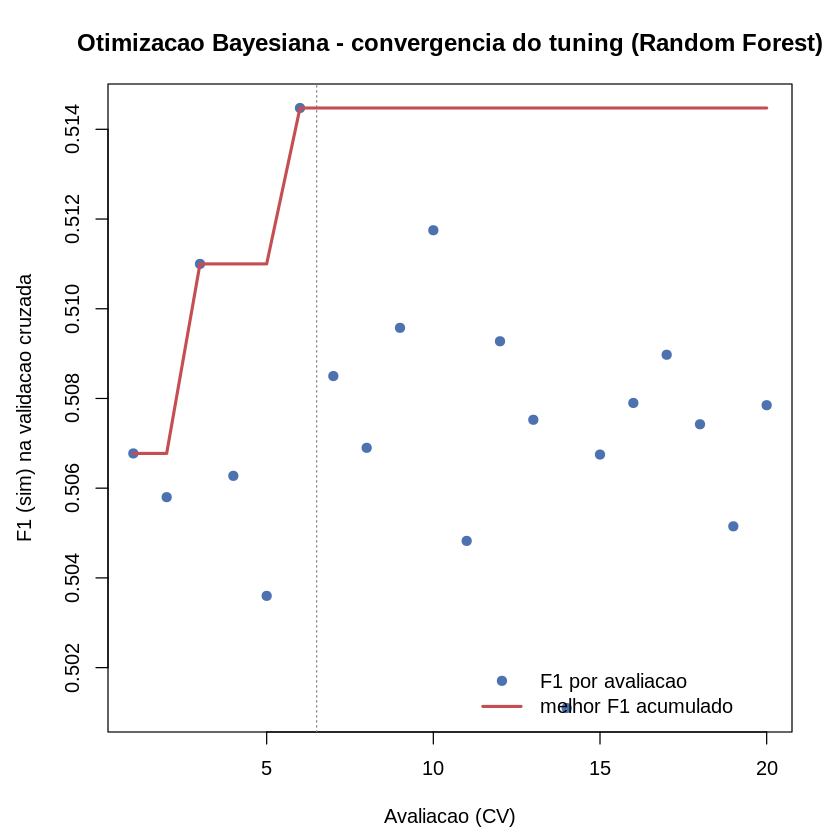

In [101]:
abrir_fig("19_tuning_convergencia", largura = 1050, altura = 680, res = 120)
par(mar = c(4.5, 4.5, 3.5, 2))
plot(seq_along(res$y), res$y, pch = 19, col = COR_NAO, xlab = "Avaliacao (CV)",
     ylab = "F1 (sim) na validacao cruzada",
     main = "Otimizacao Bayesiana - convergencia do tuning (Random Forest)")
lines(seq_along(res$y), cummax(res$y), lwd = 2.5, col = COR_SIM)
abline(v = res$n_init + 0.5, lty = 3, col = "gray50")
legend("bottomright", bty = "n", pch = c(19, NA), lwd = c(NA, 2.5), col = c(COR_NAO, COR_SIM),
       legend = c("F1 por avaliacao", "melhor F1 acumulado"))
fechar_fig()

**Conclusão:** o melhor F1 acumulado (linha vermelha) estabiliza ainda nas avaliações iniciais (antes da linha pontilhada que marca o fim da fase de exploração aleatória) e as iterações bayesianas subsequentes não conseguem superá-lo de forma consistente — os pontos azuis oscilam em torno do mesmo nível, sem tendência de melhora. Esse padrão é a evidência visual de que a Random Forest é **robusta** a esses hiperparâmetros neste problema: o tuning serviu para confirmar a estabilidade da configuração, não para produzir ganho expressivo de métrica.

### 9.2 Ajuste do ponto de corte (sobre a Random Forest tunada, OOB)

In [102]:
rf_tunada <- treinar_floresta(X_treino_sel_z, y_treino01, n_arvores = 80, mtry = mtry_best,
                              max_prof = prof_best, min_no = no_best, n_cortes = 12)
ok_t <- rf_tunada$oob_cont > 0
prob_oob <- rf_tunada$oob_prob[ok_t]; y_oob <- y_treino[ok_t]
cortes <- seq(0.15, 0.75, by = 0.05)
f1_corte   <- sapply(cortes, function(c) { v <- avaliar(y_oob, classificar(prob_oob, c))$metricas$valor[5]; ifelse(is.na(v), 0, v) })
rec_corte  <- sapply(cortes, function(c) avaliar(y_oob, classificar(prob_oob, c))$metricas$valor[2])
prec_corte <- sapply(cortes, function(c) { v <- avaliar(y_oob, classificar(prob_oob, c))$metricas$valor[4]; ifelse(is.na(v), 0, v) })
corte_best <- cortes[which.max(f1_corte)]
cat(sprintf("  Ponto de corte otimo (max F1 OOB): %.2f (F1 = %.4f vs %.4f no corte 0,50)\n",
            corte_best, max(f1_corte), f1_corte[cortes == 0.5]))

  Ponto de corte otimo (max F1 OOB): 0.50 (F1 = 0.5170 vs 0.5170 no corte 0,50)


**Conclusão:** o corte de 0,50 já maximiza o F1 (≈0,517) entre os valores testados — não há ganho relevante em deslocar o limiar para esse objetivo específico. Ainda assim, a análise é útil para a decisão de negócio: cortes mais baixos (entre 0,35 e 0,40) elevam o recall para a faixa de 0,64–0,65, ao custo de mais falsos positivos — uma troca que pode valer a pena se o custo de perder um cliente que aderiria for maior do que o custo de uma ligação a um cliente que não aderirá.

### 9.3 Efeito do ponto de corte sobre F1, recall e precisão

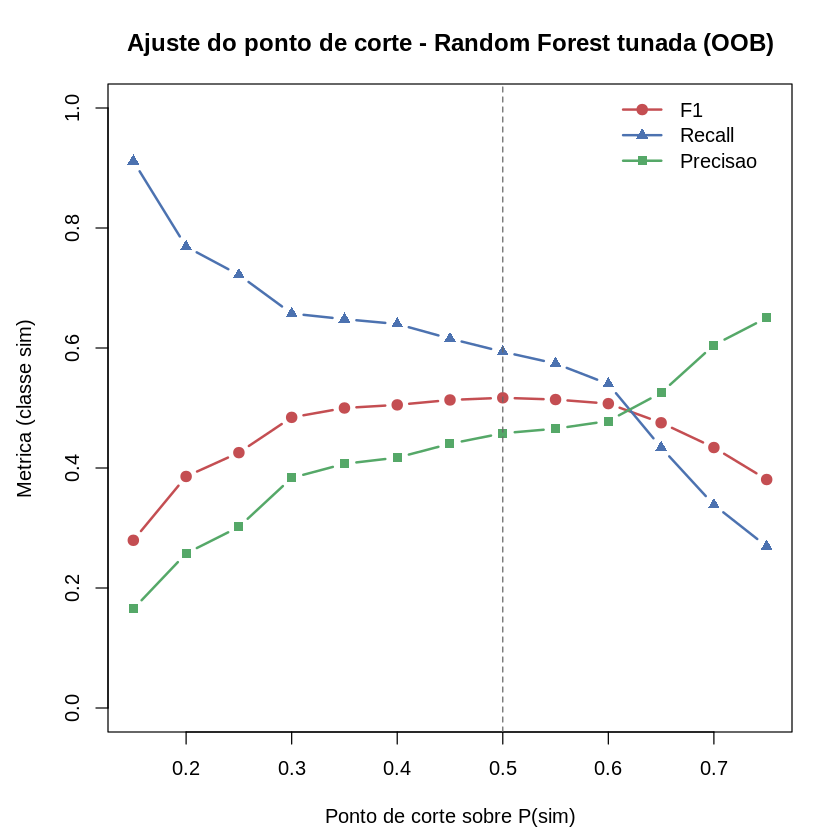

In [103]:
# Fig 20 - ajuste do ponto de corte
abrir_fig("20_tuning_corte", largura = 1050, altura = 680, res = 120)
par(mar = c(4.5, 4.5, 3.5, 2))
plot(cortes, f1_corte, type = "b", pch = 19, lwd = 2, col = COR_SIM, ylim = c(0, 1),
     xlab = "Ponto de corte sobre P(sim)", ylab = "Metrica (classe sim)",
     main = "Ajuste do ponto de corte - Random Forest tunada (OOB)")
lines(cortes, rec_corte, type = "b", pch = 17, lwd = 2, col = COR_NAO)
lines(cortes, prec_corte, type = "b", pch = 15, lwd = 2, col = COR_NEU)
abline(v = corte_best, lty = 2, col = "gray40")
legend("topright", bty = "n", pch = c(19, 17, 15), lwd = 2, col = c(COR_SIM, COR_NAO, COR_NEU),
       legend = c("F1", "Recall", "Precisao"))
fechar_fig()

**Conclusão:** a curva de recall (azul) decai suavemente com o aumento do corte e a curva de precisão (verde) sobe na direção oposta — o trade-off clássico entre as duas métricas. A curva de F1 (vermelha) tem seu pico justamente onde as outras duas se equilibram, perto do corte 0,50–0,55, confirmando esse intervalo como a escolha mais equilibrada para a avaliação final.

## 10. Avaliação final no conjunto de teste reservado

O modelo final escolhido — a Random Forest tunada (`mtry = 7`, profundidade máxima = 8, mínimo por nó = 23, 80 árvores, sobre as 17 variáveis selecionadas), com ponto de corte 0,50 — é aplicado **uma única vez** ao conjunto de teste reservado (9.144 observações, 12,7% de "Sim"), que preserva a proporção real de classes e não havia sido utilizado em nenhuma etapa anterior do projeto.

In [104]:
# 10. Avaliacao final no teste reservado (uma unica vez) - figuras 21-24
cat("\n== 10. AVALIACAO FINAL NO TESTE (uma unica vez) - figuras 21-24 ==\n")
y01_te <- as.integer(y_teste == "yes")
prob_te <- prever_floresta(rf_tunada, X_teste_sel_z)
av_te <- avaliar(y_teste, classificar(prob_te, corte_best))
auc_te <- auc_roc(prob_te, y01_te)
roc_te <- curva_roc(prob_te, y01_te)
cat("  Modelo final: Random Forest tunada (mtry=", mtry_best, ", max_prof=", prof_best,
    ", min_no=", no_best, ", arvores=80, corte=", corte_best, ")\n", sep = "")
cat("\n  Matriz de confusao (teste):\n"); print(av_te$matriz)
cat("\n  Metricas (teste):\n"); print(av_te$metricas, row.names = FALSE)

ord <- order(prob_te, decreasing = TRUE); ys <- y01_te[ord]
P <- sum(y01_te == 1); N <- sum(y01_te == 0)
prec <- cumsum(ys == 1) / (cumsum(ys == 1) + cumsum(ys == 0)); rec <- cumsum(ys == 1) / P
ap_te <- sum(prec[ys == 1]) / P; base_pr <- P / (P + N)
cat(sprintf("  AUC (ROC) = %.4f | Average Precision (PR) = %.4f | base PR = %.4f\n",
            auc_te, ap_te, base_pr))

av_oob_final <- avaliar(y_oob, classificar(prob_oob, corte_best))
auc_oob_final <- auc_roc(prob_oob, as.integer(y_oob == "yes"))
comp_gen <- data.frame(
  metrica = c(as.character(av_oob_final$metricas$metrica), "AUC (ROC)"),
  oob_treino = round(c(av_oob_final$metricas$valor, auc_oob_final), 4),
  teste = round(c(av_te$metricas$valor, auc_te), 4))
comp_gen$diferenca <- round(comp_gen$teste - comp_gen$oob_treino, 4)
cat("\n  Generalizacao - OOB (treino) x teste:\n"); print(comp_gen, row.names = FALSE)


== 10. AVALIACAO FINAL NO TESTE (uma unica vez) - figuras 21-24 ==
  Modelo final: Random Forest tunada (mtry=7, max_prof=8, min_no=23, arvores=80, corte=0.5)

  Matriz de confusao (teste):
     Predito
Real    no  yes
  no  7163  823
  yes  492  666

  Metricas (teste):
                    metrica  valor
                   Acuracia 0.8562
 Sensibilidade (recall sim) 0.5751
             Especificidade 0.8969
             Precisao (sim) 0.4473
                   F1 (sim) 0.5032
  AUC (ROC) = 0.8030 | Average Precision (PR) = 0.4810 | base PR = 0.1266

  Generalizacao - OOB (treino) x teste:
                    metrica oob_treino  teste diferenca
                   Acuracia     0.8596 0.8562   -0.0034
 Sensibilidade (recall sim)     0.5937 0.5751   -0.0186
             Especificidade     0.8981 0.8969   -0.0012
             Precisao (sim)     0.4579 0.4473   -0.0106
                   F1 (sim)     0.5170 0.5032   -0.0138
                  AUC (ROC)     0.8029 0.8030    0.0001


**Conclusão:** as diferenças entre a estimativa OOB (obtida só no treino) e o desempenho no teste são pequenas — no máximo cerca de 0,02 em valor absoluto nas métricas, e o AUC é praticamente idêntico (0,8029 no OOB vs. 0,8030 no teste). Essa proximidade é a evidência mais forte de que a estimativa OOB era confiável e que o modelo generaliza bem para dados não vistos, sem sinais de sobreajuste — exatamente o que se espera de um pipeline bem construído, em que o teste só é tocado uma vez, ao final.

### 10.1 Importância por permutação (no teste)

Diferentemente da importância por redução de Gini (Seção 7.2, calculada internamente durante o treino), a importância por permutação embaralha cada coluna do conjunto de teste e mede a queda resultante no AUC — uma medida obtida diretamente sobre o desempenho em dados não vistos.

In [105]:
# Importancia por permutacao: queda de AUC ao embaralhar cada variavel.
set.seed(SEED); N_REP <- 10; nomes_sel <- colnames(X_teste_sel_z)
imp_perm <- numeric(length(nomes_sel)); names(imp_perm) <- nomes_sel
cat("  Calculando importancia por permutacao (", N_REP, " repeticoes/variavel)...\n", sep = "")
for (j in seq_along(nomes_sel)) {
  quedas <- numeric(N_REP)
  for (r in seq_len(N_REP)) {
    Xp <- X_teste_sel_z; Xp[, j] <- X_teste_sel_z[sample(nrow(X_teste_sel_z)), j]
    quedas[r] <- auc_te - auc_roc(prever_floresta(rf_tunada, Xp), y01_te)
  }
  imp_perm[j] <- mean(quedas)
}
imp_perm <- sort(imp_perm, decreasing = TRUE)
cat("\n  Importancia por permutacao (5 maiores quedas de AUC):\n")
print(head(data.frame(variavel = names(imp_perm), queda_auc = round(as.vector(imp_perm), 5)), 5),
      row.names = FALSE)

  Calculando importancia por permutacao (10 repeticoes/variavel)...

  Importancia por permutacao (5 maiores quedas de AUC):
         variavel queda_auc
      nr.employed   0.10085
    cons.conf.idx   0.01450
 contact_cellular   0.01357
   cons.price.idx   0.01174
 poutcome_success   0.00960


**Conclusão:** `nr.employed` é, com larga vantagem, a variável mais relevante (queda de AUC em torno de 0,10 — cerca de 7 vezes maior que a segunda colocada), seguida por `cons.conf.idx`, `contact_cellular`, `cons.price.idx` e `poutcome_success`. Esse ranking é coerente com a importância por redução de Gini (Seção 7.2) e com os sinais identificados na EDA (Seção 2), o que reforça a consistência de toda a análise — do dado bruto até a avaliação final em produção.

### 10.2 Matriz de confusão (teste)

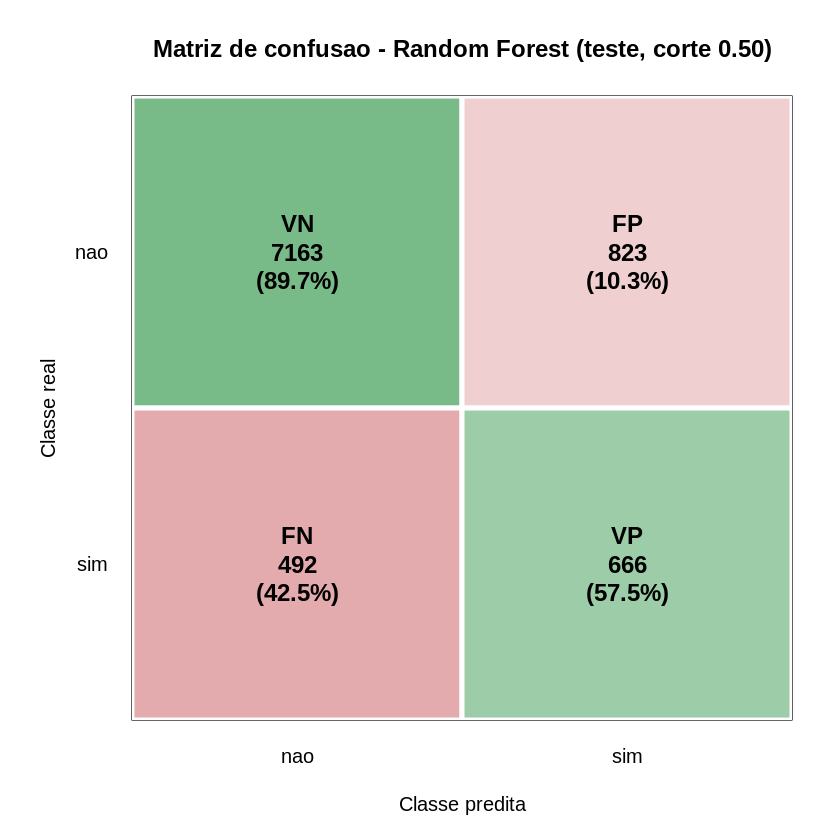

In [106]:
# Fig 21 - matriz de confusao no teste
plot_matriz_confusao(av_te$matriz, "21_teste_matriz_confusao",
                     sprintf("Matriz de confusao - Random Forest (teste, corte %.2f)", corte_best))

**Conclusão:** no conjunto de teste, a Random Forest mantém o padrão observado no OOB: bom equilíbrio entre identificar a maioria dos clientes que aderem (recall 0,58) e um nível de falsos positivos administrável (especificidade 0,90). Esse é o resultado que de fato importa para validar o modelo, pois é a única avaliação feita sobre dados completamente não vistos durante a construção do pipeline.

### 10.3 Curva ROC (teste)

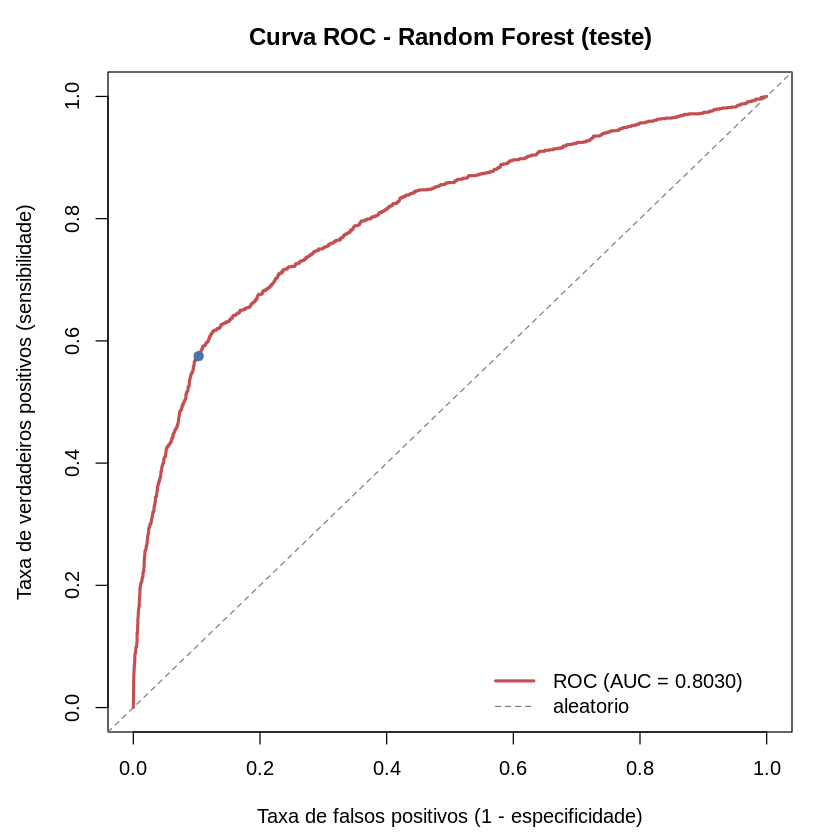

In [107]:
# Fig 22 - curva ROC no teste
abrir_fig("22_teste_roc", largura = 820, altura = 760, res = 120)
par(mar = c(4.5, 4.5, 3, 2))
plot(roc_te$taxa_fp, roc_te$taxa_vp, type = "l", lwd = 2.5, col = COR_SIM,
     xlim = c(0, 1), ylim = c(0, 1),
     xlab = "Taxa de falsos positivos (1 - especificidade)",
     ylab = "Taxa de verdadeiros positivos (sensibilidade)",
     main = "Curva ROC - Random Forest (teste)")
abline(0, 1, lty = 2, col = "gray50")
points(1 - av_te$metricas$valor[3], av_te$metricas$valor[2], pch = 19, col = COR_NAO)
legend("bottomright", bty = "n", lwd = c(2.5, 1), lty = c(1, 2), col = c(COR_SIM, "gray50"),
       legend = c(sprintf("ROC (AUC = %.4f)", auc_te), "aleatorio"))
fechar_fig()

**Conclusão:** o AUC de 0,8030 no teste confirma a boa capacidade discriminativa do modelo, de forma praticamente idêntica à estimativa OOB (0,8029) — não há indício de queda de desempenho ao migrar do treino para dados novos.

### 10.4 Curva Precision-Recall (teste)

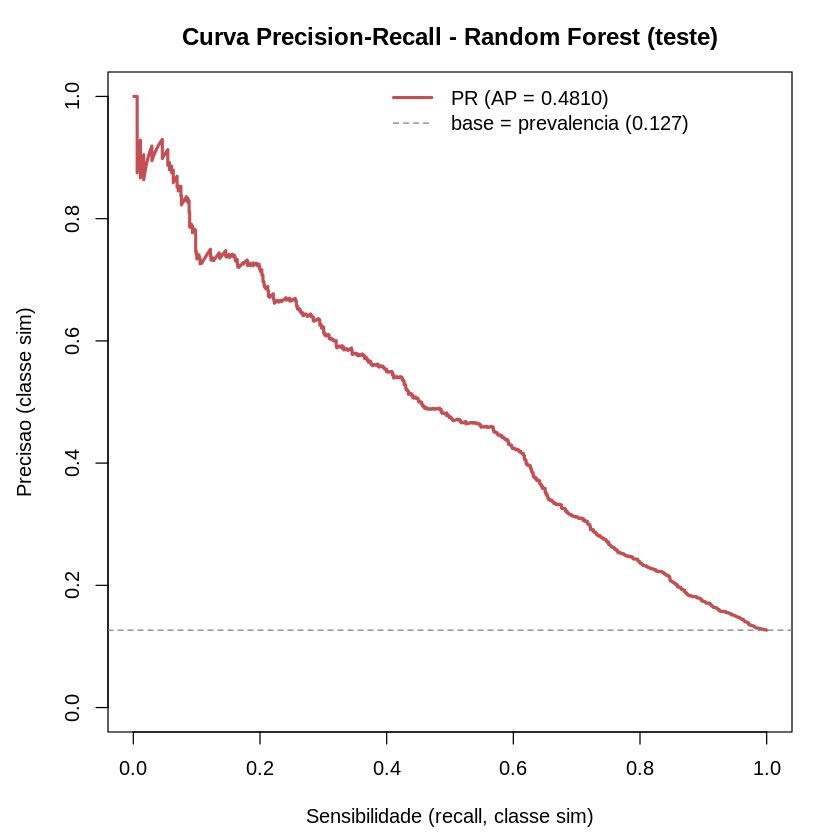

In [108]:
# Fig 23 - curva Precision-Recall no teste
abrir_fig("23_teste_pr", largura = 820, altura = 760, res = 120)
par(mar = c(4.5, 4.5, 3, 2))
plot(rec, prec, type = "l", lwd = 2.5, col = COR_SIM, xlim = c(0, 1), ylim = c(0, 1),
     xlab = "Sensibilidade (recall, classe sim)", ylab = "Precisao (classe sim)",
     main = "Curva Precision-Recall - Random Forest (teste)")
abline(h = base_pr, lty = 2, col = "gray50")
legend("topright", bty = "n", lwd = c(2.5, 1), lty = c(1, 2), col = c(COR_SIM, "gray50"),
       legend = c(sprintf("PR (AP = %.4f)", ap_te), sprintf("base = prevalencia (%.3f)", base_pr)))
fechar_fig()

**Conclusão:** a *Average Precision* (área sob a curva PR) é 0,4810, cerca de 3,8 vezes a linha de base definida pela prevalência da classe "Sim" (0,1266). Como a curva Precision-Recall é mais informativa do que a ROC em cenários de forte desbalanceamento, esse resultado é uma evidência adicional — e mais rigorosa — de que o modelo carrega sinal preditivo real, e não apenas vantagem decorrente do desbalanceamento da base.

### 10.5 Importância por permutação — visualização final

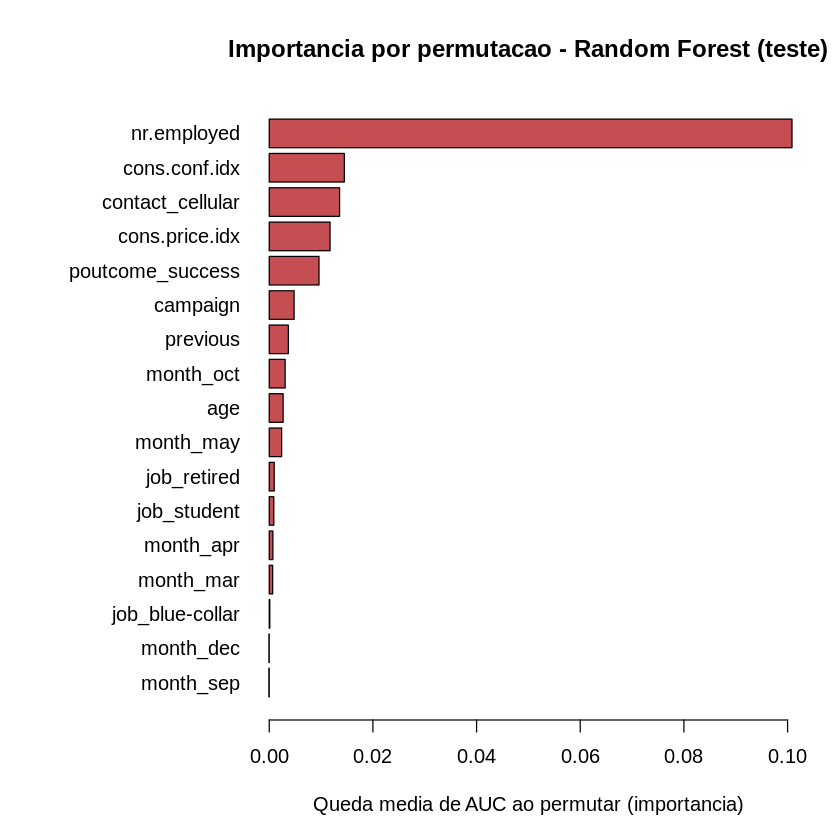

In [109]:
# Fig 24 - importancia por permutacao no teste
impb <- imp_perm[order(imp_perm)]
abrir_fig("24_teste_importancia_permutacao", largura = 1100, altura = 900, res = 120)
par(mar = c(5, 11, 4, 2))
barplot(as.vector(impb), horiz = TRUE, names.arg = names(impb), las = 1, col = COR_SIM,
        xlab = "Queda media de AUC ao permutar (importancia)",
        main = "Importancia por permutacao - Random Forest (teste)")
fechar_fig()

**Conclusão:** o gráfico horizontal evidencia visualmente a distância entre `nr.employed` e as demais variáveis: nenhuma outra variável, isolada, aproxima-se da sua contribuição para o AUC. Isso indica que o cenário macroeconômico do momento do contato (sintetizado por essa variável) é o fator dominante na propensão à adesão — um achado relevante tanto para a interpretação do modelo quanto para o planejamento de campanhas (ver Conclusão, a seguir).

## Conclusão

### Modelo escolhido e principais achados

Construiu-se um pipeline completo e reprodutível de classificação supervisionada sobre a base *Bank Marketing*, contemplando limpeza, EDA, pré-processamento sem vazamento, seleção de variáveis por correlação e dois modelos implementados manualmente (Regressão Logística e Random Forest), além do tratamento do desbalanceamento.

Após a comparação dos resultados, decidiu-se utilizar a **Random Forest** como modelo final. A decisão fundamenta-se no melhor compromisso entre as métricas adequadas ao problema (recall 0,61 e F1 0,52, por OOB, à frente da logística com undersampling), na capacidade de captar interações entre variáveis, na robustez a escala e a redundância, e na estabilidade frente aos hiperparâmetros confirmada pelo tuning. A avaliação no conjunto de teste reservado confirmou essa escolha, com recall 0,58, F1 0,50 e AUC 0,80 em dados não vistos.

**Principais achados:**

- O **desbalanceamento é o fator dominante**: a acurácia é enganosa e o recall e o F1 da classe "Sim" são as métricas que de fato orientam as decisões.
- A **Random Forest** apresenta o melhor compromisso entre recall e precisão, à frente da logística com undersampling.
- A **seleção por correlação** reduziu o conjunto de 56 para 17 variáveis, atenuou a multicolinearidade da logística e acelerou seu ajuste em cerca de 17 vezes, sem prejudicar a Random Forest.
- O **tuning por otimização bayesiana** confirmou que a Random Forest é robusta aos hiperparâmetros (F1 em torno de 0,517, estável), com ponto de corte ótimo em 0,50.
- No conjunto de teste reservado, a Random Forest final manteve o desempenho estimado por OOB (recall 0,58, F1 0,50, AUC 0,80), com diferenças inferiores a 0,02 — evidência de boa generalização e ausência de sobreajuste.

### Impacto para a instituição

A adoção de um modelo preditivo de adesão tem efeito direto sobre a eficiência das campanhas de telemarketing. Ao ordenar os clientes pela probabilidade estimada de adesão, a instituição pode priorizar os contatos de maior potencial e reduzir o volume de ligações com baixa expectativa de retorno, diminuindo o custo operacional por conversão. Em um cenário de desbalanceamento em que apenas cerca de 12,7% dos clientes aderem, a elevação do recall obtida pela Random Forest significa recuperar uma parcela relevante de aderentes que um critério baseado em acurácia tenderia a ignorar.

Como desdobramentos futuros, o modelo pode ser incorporado ao fluxo de planejamento das campanhas para segmentar a base e definir prioridades de contato, com o ponto de corte calibrado segundo o custo relativo de cada ligação e a meta de conversão. As medidas de importância de variáveis fornecem, ainda, subsídios de negócio sobre quais fatores — indicadores macroeconômicos, resultado de campanhas anteriores e meio de contato — mais se associam à adesão, informando o momento e a forma de abordagem.

### Limitações e próximos passos

A precisão da classe "Sim" permanece moderada (cerca de 0,45 no teste): parte dos clientes sinalizados como propensos não adere, comportamento esperado em cenários desbalanceados e que pode ser calibrado pelo ponto de corte conforme o custo relativo de cada contato. Além disso, os indicadores macroeconômicos — fortemente associados à adesão — variam ao longo do tempo, de modo que o desempenho deve ser monitorado em campanhas de períodos distintos. Como melhorias futuras, podem-se comparar outras estratégias de balanceamento (por exemplo, SMOTE), estender o tuning também à Regressão Logística e avaliar periodicamente a necessidade de re-treino do modelo.




